# Capstone — Bayesian Optimisation (Week 7, refactored)
Config-driven dispatcher with a surrogate trust gate, regularised kernel (Matérn + WhiteKernel + lengthscale floor), multi-method dimension importance, frozen-dim acquisition, and diagonal-Thompson TuRBO — with all original diagnostic plots retained.

In [388]:
%reset -f

In [389]:

%matplotlib inline
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib.colors as mcolors, matplotlib.cm as cm
np.random.seed(42)

In [390]:
# LOADING FUNCTION VALUES
DATA_DIR = "initial_data_9"
def load_function(fn_num):
    X_read = np.load(f'{DATA_DIR}/function_{fn_num}/initial_inputs.npy')
    y_read = np.load(f'{DATA_DIR}/function_{fn_num}/initial_outputs.npy')
    cols = [f'x{i+1}' for i in range(X_read.shape[1])]
    X = pd.DataFrame(X_read, columns=cols)
    y = pd.Series(y_read, name='y')
    return X, y

X1, y1 = load_function(1)
X2, y2 = load_function(2)
X3, y3 = load_function(3)
X4, y4 = load_function(4)
X5, y5 = load_function(5)
X6, y6 = load_function(6)
X7, y7 = load_function(7)
X8, y8 = load_function(8)

all_X = [X1, X2, X3, X4, X5, X6, X7, X8]
all_y = [y1, y2, y3, y4, y5, y6, y7, y8]

## Pipeline
Kernel + trust gate, multi-method importance, acquisitions/strategies, and the config-driven `run_all`. Edit `CONFIG` to steer any function; leave `strategy='auto'` to let the LOO gate route it.

In [391]:
# =====================================================================
#  BBO capstone pipeline  —  Week 10
#  Changes vs W9:
#    P0  NaN-safe warp_inv / loo_cv / route   (F7 was routed by a NaN)
#    P1  ARD saturation read as MULTIMODAL, not irrelevant (LS_UPPER 1e4 -> 20)
#    P2  multi-basin TuRBO round-robin                     (F2)
#    P3  local-GP needle refinement                        (F4)
# =====================================================================
import numpy as np, pandas as pd
from dataclasses import dataclass, field
from scipy.stats import norm, qmc
from scipy.optimize import differential_evolution
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import PowerTransformer

RNG = np.random.default_rng(42)

def fn_rng(fn, week=None):
    """Per-function generator. Each function draws from its own stream, so a
    config change to one function cannot perturb another's suggestion."""
    return np.random.default_rng([42, int(fn), int(WEEK if week is None else week)])
EPS, UB, LS_UPPER = 1e-6, 1-1e-6, 20.0      # P1: was 1e4
WEEK = 10                                    # drives multi-basin round-robin

# ------------------------- SPEED KNOBS -------------------------
# Defaults below are the FAST path, for iterating on plots/config.
# Before quoting numbers in the report, set REPORT_MODE = True.
REPORT_MODE   = False
REFIT_HYPERS  = REPORT_MODE   # refit GP hypers on every LOO fold (~12x slower)
COMPARE_LOO   = REPORT_MODE   # also compute the old warped-scale BEFORE column
PERM_REPEATS  = 30 if REPORT_MODE else 10
RF_TREES      = 300 if REPORT_MODE else 150
GP_RESTARTS   = None          # None -> max(5, 2*d);  int -> fixed
# ---------------------------------------------------------------


def load_function(fn):
    X = np.load(f"{DATA_DIR}/function_{fn}/initial_inputs.npy")
    Y = np.load(f"{DATA_DIR}/function_{fn}/initial_outputs.npy").ravel()
    cols = [f"x{i+1}" for i in range(X.shape[1])]
    return pd.DataFrame(X, columns=cols), pd.Series(Y, name="y")


@dataclass
class FnConfig:
    strategy: str = "auto"; warp: str | None = None; ls_floor: float = 0.05
    noise: bool = True; freeze: bool = True; n_candidates: int = 4000
    nu: float = 2.5; override_frozen: tuple = ()
    min_sep: float = 0.25; radius: float = 0.20        # P2 / P3
    shrink: float = 0.06; xi: float = 0.001            # P3
    basin_rank: str = "y"                              # "y" or "abs" (envelope)
    turbo_ti: float = 0.4                              # initial trust-region length
    max_basins: int = 3                                # anchors in the round-robin


CONFIG = {1: FnConfig(strategy="turbo_mb", warp=None,  nu=1.5,
                      basin_rank="y", min_sep=0.10, turbo_ti=0.09, max_basins=1),
          2: FnConfig(strategy="turbo_mb",              nu=2.5, min_sep=0.25),
          3: FnConfig(strategy="auto",     warp="yeo", nu=1.5),
          4: FnConfig(strategy="turbo",    warp="yeo", nu=1.5),
          5: FnConfig(strategy="global",   warp="yeo", nu=2.5),
          6: FnConfig(strategy="auto",     warp="yeo", nu=1.5),
          7: FnConfig(strategy="auto",     warp="yeo", nu=1.5),
          8: FnConfig(strategy="auto",     warp="yeo", nu=2.5)}


def build_kernel(nd, cfg):
    k = Matern(np.ones(nd), (cfg.ls_floor, LS_UPPER), nu=cfg.nu)
    return k + WhiteKernel(1e-3, (1e-6, 1.0)) if cfg.noise else k


def make_gp(X, Y, cfg):
    gp = GaussianProcessRegressor(build_kernel(X.shape[1], cfg),
        alpha=1e-10 if cfg.noise else 1e-6,
        n_restarts_optimizer=GP_RESTARTS or max(5, 2*X.shape[1]),
        normalize_y=True, random_state=42)
    return gp.fit(X, Y)


# ---------- warp: fit on a slice, apply, invert (array-safe) ----------
def fit_warp(Ytr, w):
    if w == "log":
        s = 0.0 if Ytr.min() > 0 else 1 - Ytr.min(); return ("log", s)
    if w == "yeo":
        return ("yeo", PowerTransformer("yeo-johnson").fit(Ytr.reshape(-1, 1)))
    return (None, None)


def warp_apply(Y, m):
    k, o = m
    if k == "log": return np.log(Y + o)
    if k == "yeo": return o.transform(Y.reshape(-1, 1)).ravel()
    return Y


def warp_inv(y, m):
    """P0: Yeo-Johnson with lambda<0 has a pole at z=-1/lambda. A GP prediction
    past it returns NaN, which poisons LOO R2 and silently reroutes."""
    k, o = m
    y = np.atleast_1d(np.asarray(y, float))
    if k == "log":
        return np.exp(np.clip(y, -700, 700)) - o
    if k == "yeo":
        lam = float(o.lambdas_[0])
        if lam < 0:
            y = np.minimum(y, (-1.0 / lam) - 1e-8)
        elif lam > 2:
            y = np.maximum(y, (1.0 / (2.0 - lam)) + 1e-8)
        out = o.inverse_transform(y.reshape(-1, 1)).ravel()
        if not np.isfinite(out).all():
            fill = np.nanmin(out[np.isfinite(out)]) if np.isfinite(out).any() else 0.0
            out = np.nan_to_num(out, nan=fill, posinf=fill, neginf=fill)
        return out
    return y


def warp_fwd(Y, w):
    m = fit_warp(Y, w); return warp_apply(Y, m), m


def matern_ls(gp):
    k = gp.kernel_
    return np.atleast_1d(k.k1.length_scale if hasattr(k, "k1") else k.length_scale)


# ---------- LOO CV: raw-scale score, per-fold warp, NaN-safe ----------
def loo_cv(X, Yraw, cfg, refit_hypers=None):
    """Raw-scale LOO R2, per-fold warp, NaN-safe.

    refit_hypers=False (the fast default) tunes the kernel ONCE on the full
    data and reuses it for every fold via optimizer=None -- ~12x faster.
    This is mildly optimistic: the shared hyperparameters have seen the
    held-out point. Use REPORT_MODE=True for the numbers you actually quote.
    """
    if refit_hypers is None:
        refit_hypers = REFIT_HYPERS

    ktuned = None
    if not refit_hypers:
        m0 = fit_warp(Yraw, cfg.warp)
        ktuned = GaussianProcessRegressor(build_kernel(X.shape[1], cfg),
            alpha=1e-10 if cfg.noise else 1e-6, n_restarts_optimizer=3,
            normalize_y=True, random_state=42).fit(X, warp_apply(Yraw, m0)).kernel_

    p_raw = np.full(len(Yraw), np.nan)
    for tr, te in LeaveOneOut().split(X):
        m = fit_warp(Yraw[tr], cfg.warp)          # warp still refits per fold
        g = (GaussianProcessRegressor(build_kernel(X.shape[1], cfg),
                 alpha=1e-10 if cfg.noise else 1e-6,
                 n_restarts_optimizer=3, normalize_y=True, random_state=42)
             if refit_hypers else
             GaussianProcessRegressor(ktuned, optimizer=None,
                 alpha=1e-10 if cfg.noise else 1e-6, normalize_y=True,
                 random_state=42))
        g.fit(X[tr], warp_apply(Yraw[tr], m))
        pw = g.predict(X[te])
        p_raw[te] = warp_inv(pw, m) if cfg.warp else pw

    ok = np.isfinite(p_raw)
    if ok.sum() < 3:
        return p_raw, -np.inf
    if ok.sum() < len(Yraw):
        print(f"    [loo_cv] dropped {(~ok).sum()}/{len(Yraw)} non-finite folds")
    r2 = 1 - np.sum((Yraw[ok]-p_raw[ok])**2) / (np.sum((Yraw[ok]-Yraw[ok].mean())**2) + 1e-12)
    return p_raw, r2


def loo_cv_warped(X, Yw, cfg):
    """Original behaviour, kept ONLY to populate the BEFORE column."""
    p = np.zeros(len(Yw))
    for tr, te in LeaveOneOut().split(X):
        g = GaussianProcessRegressor(build_kernel(X.shape[1], cfg),
            alpha=1e-10 if cfg.noise else 1e-6, n_restarts_optimizer=3,
            normalize_y=True, random_state=42).fit(X[tr], Yw[tr])
        p[te] = g.predict(X[te])
    r2 = 1 - np.sum((Yw-p)**2) / (np.sum((Yw-Yw.mean())**2) + 1e-12)
    return p, r2


def _n01(v):
    v = np.clip(np.asarray(v, float), 0, None); return v/v.max() if v.max() > 0 else v


def gp_grad_sens(gp, nd, ns=512, h=1e-3):
    Xs = np.clip(qmc.Sobol(d=nd, seed=42).random(ns), EPS, UB)
    base = gp.predict(Xs); g = np.zeros(nd)
    for j in range(nd):
        Xp = Xs.copy(); Xp[:, j] = np.clip(Xp[:, j]+h, EPS, UB)
        g[j] = np.sqrt(np.mean(((gp.predict(Xp)-base)/h)**2))
    return g


# ---------- P1: saturation = multimodality, not irrelevance ----------
def diagnose_saturation(gp, noise_thresh=0.02):
    """A stationary Matern cannot represent two separated basins in one dim.
    Its least-bad fit is ls -> upper bound (flatten it) with the mode-to-mode
    variance dumped into WhiteKernel. Both symptoms together = multimodal."""
    k = gp.kernel_
    ls = np.atleast_1d(k.k1.length_scale if hasattr(k, "k1") else k.length_scale)
    noise = k.k2.noise_level if hasattr(k, "k2") else 0.0
    saturated = ls >= 0.5 * LS_UPPER
    return {"lengthscales": ls, "noise": float(noise),
            "saturated_dims": np.where(saturated)[0],
            "multimodal_flag": bool(saturated.any() and noise > noise_thresh)}


def guard_freeze(frozen, sat):
    """Never freeze a dimension flagged as multimodal."""
    frozen = np.asarray(frozen).copy()
    if sat["multimodal_flag"]:
        frozen[sat["saturated_dims"]] = False
    return frozen


def dimension_importance(X, Y, gp, cfg):
    nd = X.shape[1]; ls = matern_ls(gp)
    ard = _n01(1/np.clip(ls, 1e-6, None)); grad = _n01(gp_grad_sens(gp, nd))
    rf = RandomForestRegressor(RF_TREES, random_state=42, n_jobs=-1).fit(X, Y)
    perm = _n01(permutation_importance(rf, X, Y, n_repeats=PERM_REPEATS,
                                       random_state=42, n_jobs=-1).importances_mean)
    try:
        import shap
        sv = shap.TreeExplainer(rf).shap_values(X, check_additivity=False)
        shp = _n01(np.abs(sv).mean(0))
    except Exception:
        shp = np.full(nd, np.nan)
    gp_fam = np.nanmean(np.vstack([ard, grad]), 0)
    rf_fam = np.nanmean(np.vstack([perm, shp]), 0)
    cons = np.nanmean(np.vstack([gp_fam, rf_fam]), 0)
    disagree = np.abs(gp_fam - rf_fam)

    sat = diagnose_saturation(gp)
    saturated = ls >= 0.5*LS_UPPER
    frozen = saturated & (gp_fam < 0.15) & (rf_fam < 0.15)
    for j in cfg.override_frozen: frozen[j] = True
    if not cfg.freeze: frozen[:] = False
    frozen = guard_freeze(frozen, sat)                      # P1

    return pd.DataFrame({"dim":[f"x{j+1}" for j in range(nd)], "ard":np.round(ard,3),
        "gp_grad":np.round(grad,3), "rf_perm":np.round(perm,3), "shap":np.round(shp,3),
        "gp_fam":np.round(gp_fam,3), "rf_fam":np.round(rf_fam,3),
        "consensus":np.round(cons,3), "disagree":np.round(disagree,3),
        "lengthscale":np.round(ls,2), "saturated":saturated, "frozen":frozen})


def aEI(m,s,ym,ys,xi=0.01):
    x=xi*max(ys,1e-6); z=(m-ym-x)/(s+1e-9)
    e=(m-ym-x)*norm.cdf(z)+s*norm.pdf(z); e[s<1e-10]=0; return e
def aUCB(m,s,t,d):
    return m+min(np.sqrt(2*np.log(d*t**2*np.pi**2/3.0)),3.0)*s
def aPI(m,s,ym,ys,xi=0.01):
    x=xi*max(ys,1e-6); return norm.cdf((m-ym-x)/(s+1e-9))


def _opt_active(score, anchor, active, ps=20, mi=50):
    nd = len(anchor)
    if not active: return anchor.copy()
    def neg(x):
        x = np.atleast_2d(x)
        if x.shape[0] == len(active) and x.shape[1] != len(active): x = x.T
        full = np.tile(anchor, (x.shape[0], 1)); full[:, active] = x
        s = -np.atleast_1d(score(full)); return s if s.shape[0] > 1 else s[0]
    r = differential_evolution(neg, [(EPS,UB)]*len(active), vectorized=True,
        updating="deferred", popsize=ps, maxiter=mi, tol=1e-7, seed=42, polish=True)
    out = anchor.copy(); out[active] = np.clip(r.x, EPS, UB); return out


def suggest_global(X, Y, gp, imp, cfg):
    nd=X.shape[1]; ys=Y.std(); ym=Y.max(); xb=X[np.argmax(Y)]
    active=[j for j in range(nd) if not imp["frozen"].iloc[j]]
    def mk(n):
        def sc(f):
            m,s=gp.predict(f,return_std=True)
            return aEI(m,s,ym,ys) if n=="EI" else (aUCB(m,s,len(Y),max(len(active),1)) if n=="UCB" else aPI(m,s,ym,ys))
        return sc
    return [(n, _opt_active(mk(n), xb, active), None) for n in ("EI","UCB","PI")]


def suggest_explore(X, Y, gp, imp, cfg, rng=None):
    rng = RNG if rng is None else rng
    nd=X.shape[1]; xb=X[np.argmax(Y)]
    C = rng.uniform(EPS, UB, (cfg.n_candidates, nd))
    for j in range(nd):
        if imp["frozen"].iloc[j]: C[:,j]=xb[j]
    d=np.min(np.linalg.norm(C[:,None,:]-X[None,:,:],axis=2),axis=1)
    return [("MD", np.clip(C[np.argmax(d)],EPS,UB), None)], None


TURBO_STATE = {}
NEEDLE_STATE = {}


def suggest_turbo(fn, X, Y, gp, imp, cfg, ti=None, tmin=0.05, tmax=0.8, st_=3, ft=3,
                  rng=None):
    rng = RNG if rng is None else rng
    ti = cfg.turbo_ti if ti is None else ti
    tmin = min(tmin, ti)
    nd=X.shape[1]; ym=Y.max(); xb=X[np.argmax(Y)]
    s=TURBO_STATE.setdefault(fn,{"length":ti,"succ":0,"fail":0,"last":ym})
    if ym>s["last"]: s["succ"]+=1; s["fail"]=0
    else: s["fail"]+=1; s["succ"]=0
    if s["succ"]>=st_: s["length"]=min(tmax,s["length"]*2); s["succ"]=0
    elif s["fail"]>=ft: s["length"]=max(tmin,s["length"]/2); s["fail"]=0
    s["last"]=ym; L=s["length"]
    ls=np.clip(matern_ls(gp),1e-3,1.0)          # P1: cap so a saturated dim
    active_mask=~imp["frozen"].values           #     can't distort the box
    ls_ref=ls[active_mask].mean() if active_mask.any() else ls.mean()
    half=np.clip((L/2)*(ls/ls_ref),1e-6,0.5)
    lo=np.clip(xb-half,EPS,UB); hi=np.clip(xb+half,EPS,UB); sig=(hi-lo)/4
    s["lo"], s["hi"], s["xb"], s["half"] = lo, hi, xb, half
    s["basin"], s["n_basins"] = int(np.argmax(Y)), 1
    C=np.clip(xb+sig*rng.standard_normal((cfg.n_candidates,nd)),lo,hi)
    for j in range(nd):
        if imp["frozen"].iloc[j]: C[:,j]=xb[j]
    m,sd=gp.predict(C,return_std=True); draw=m+sd*rng.standard_normal(len(m))
    return [("TuRBO", np.clip(C[np.argmax(draw)],EPS,UB), None)], L


# ---------- P2: multi-basin TuRBO  (F2) ----------
def find_basins(X, Y, min_sep=0.25, top_frac=0.5, max_basins=3, rank="y"):
    """Greedy: walk points best-first, keep those >= min_sep from all kept.

    rank="y"   : rank by signed y  -- the usual case, chases high values.
    rank="abs" : rank by |y|       -- for oscillatory functions where the
                 largest ENVELOPE may sit at a large-magnitude NEGATIVE point,
                 with a positive lobe of similar amplitude nearby (F1).
    """
    score = np.abs(Y) if rank == "abs" else Y
    order = np.argsort(-score)
    n_keep = max(3, int(len(Y) * top_frac))
    anchors = []
    for i in order[:n_keep]:
        if all(np.linalg.norm(X[i] - X[a]) >= min_sep for a in anchors):
            anchors.append(int(i))
        if len(anchors) >= max_basins:
            break
    return anchors


def suggest_turbo_multibasin(fn, X, Y, gp, imp, cfg, week=0,
                             ti=None, tmin=0.05, tmax=0.8, st_=3, ft=3,
                             rng=None):
    rng = RNG if rng is None else rng
    ti = cfg.turbo_ti if ti is None else ti
    tmin = min(tmin, ti)
    """F2 has two basins along the ridge x1~0.70. TuRBO anchored on argmax(Y)
    gives x2 in [0.535, 1.0] and can never reach the low-x2 basin."""
    nd = X.shape[1]
    anchors = find_basins(X, Y, min_sep=cfg.min_sep, rank=cfg.basin_rank,
                          max_basins=cfg.max_basins)
    b = anchors[week % len(anchors)]                 # round-robin
    xb, ym = X[b], Y[b]

    s = TURBO_STATE.setdefault((fn, b),
                               {"length": ti, "succ": 0, "fail": 0, "last": ym})
    if ym > s["last"] + 1e-9: s["succ"] += 1; s["fail"] = 0
    else:                     s["fail"] += 1; s["succ"] = 0
    if s["succ"] >= st_:   s["length"] = min(tmax, s["length"]*2); s["succ"] = 0
    elif s["fail"] >= ft:  s["length"] = max(tmin, s["length"]/2); s["fail"] = 0
    s["last"] = ym; L = s["length"]

    ls = np.clip(matern_ls(gp), 1e-3, 1.0)           # caps the saturation blow-up
    active = ~imp["frozen"].values
    ls_ref = ls[active].mean() if active.any() else ls.mean()
    half = np.clip((L/2)*(ls/ls_ref), 1e-6, 0.5)

    lo = np.clip(xb-half, EPS, UB); hi = np.clip(xb+half, EPS, UB)
    s["lo"], s["hi"], s["xb"], s["half"] = lo, hi, xb, half
    s["basin"], s["n_basins"] = b, len(anchors)
    TURBO_STATE[fn] = s                              # int-keyed alias for plots

    sig = (hi-lo)/4
    C = np.clip(xb + sig*rng.standard_normal((cfg.n_candidates, nd)), lo, hi)
    for j in range(nd):
        if imp["frozen"].iloc[j]: C[:, j] = xb[j]
    m, sd = gp.predict(C, return_std=True)
    draw = m + sd*rng.standard_normal(len(m))
    return [("TuRBO-mb", np.clip(C[np.argmax(draw)], EPS, UB), None)], L


# ---------- P3: local-GP needle refinement  (F4) ----------
def local_gp(X, Y, centre, radius=0.20, min_pts=12, nu=2.5, ls_cap=0.25):
    """Restricting the data is what lets the marginal likelihood support a
    short lengthscale; lowering ls_floor on the global fit does nothing."""
    d = np.linalg.norm(X - centre, axis=1)
    m = d <= radius
    if m.sum() < min_pts:
        m = d <= np.sort(d)[min(min_pts, len(d)) - 1]
    Xl, Yl = X[m], Y[m]
    k = Matern(np.full(X.shape[1], 0.05), (1e-3, ls_cap), nu=nu) \
        + WhiteKernel(1e-4, (1e-8, 1e-1))
    gp = GaussianProcessRegressor(k, alpha=1e-10, n_restarts_optimizer=12,
                                  normalize_y=True, random_state=42).fit(Xl, Yl)
    return gp, int(m.sum())


def suggest_needle(fn, X, Y, cfg, centre=None, n_cand=20000, rng=None):
    """Tight EI inside a small box around the incumbent, on a LOCAL GP."""
    rng = RNG if rng is None else rng
    nd = X.shape[1]
    xb = X[np.argmax(Y)] if centre is None else np.asarray(centre, float)
    lgp, npts = local_gp(X, Y, xb, radius=cfg.radius, nu=cfg.nu)
    lo = np.clip(xb - cfg.shrink, EPS, UB); hi = np.clip(xb + cfg.shrink, EPS, UB)
    C = rng.uniform(lo, hi, size=(n_cand, nd))
    m, s = lgp.predict(C, return_std=True)
    ym, ys = Y.max(), Y.std()
    x_ = cfg.xi * max(ys, 1e-6)
    z = (m - ym - x_) / (s + 1e-9)
    ei = (m - ym - x_)*norm.cdf(z) + s*norm.pdf(z)
    ei[s < 1e-10] = 0
    NEEDLE_STATE[fn] = {"lo": lo, "hi": hi, "xb": xb, "n_local": npts,
                        "local_ls": np.atleast_1d(lgp.kernel_.k1.length_scale),
                        "length": float(cfg.shrink*2)}
    return [("EI-needle", np.clip(C[np.argmax(ei)], EPS, UB), None)], npts


def route(r2, imp):
    """P0: NaN-safe. An unusable R2 now routes to 'explore', not silently turbo."""
    if not np.isfinite(r2):
        return "explore"
    if not (imp["consensus"] > 0.15).any():
        return "explore"
    return "global" if r2 >= 0.30 else "turbo"


def run_all(fns=range(1,9), verbose=True, compare_loo=None):
    if compare_loo is None: compare_loo = COMPARE_LOO
    all_X=[load_function(f)[0] for f in range(1,9)]
    all_y=[load_function(f)[1] for f in range(1,9)]
    df_all_rows=[]; best_rows=[]; gps={}; diagnostics={}; top_dims={}; cmp_rows=[]
    for fn in fns:
        cfg=CONFIG.get(fn,FnConfig()); Xdf,Ydf=all_X[fn-1],all_y[fn-1]
        X=Xdf.values; Yraw=Ydf.values; cols=Xdf.columns.tolist()
        Yw,wm=warp_fwd(Yraw,cfg.warp)
        gp=make_gp(X,Yw,cfg); gps[fn]=gp

        r2_before = loo_cv_warped(X,Yw,cfg)[1] if compare_loo else np.nan
        loo_p,r2  = loo_cv(X,Yraw,cfg)

        imp=dimension_importance(X,Yw,gp,cfg)
        sat=diagnose_saturation(gp)
        diagnostics[fn]={"loo_r2":r2,"loo_r2_before":r2_before,
                         "loo_preds_raw":loo_p,"loo_true_raw":Yraw,
                         "importance":imp,"saturation":sat}
        top_dims[fn]=imp.sort_values("consensus",ascending=False)["dim"].tolist()

        strat=route(r2,imp) if cfg.strategy=="auto" else cfg.strategy
        would=route(r2,imp)
        cmp_rows.append({"function":fn,"d":X.shape[1],"warp":cfg.warp or "-","nu":cfg.nu,
            "loo_r2_before":round(r2_before,3),"loo_r2_after":round(r2,3),
            "delta":round(r2-r2_before,3),
            "route_before":route(r2_before,imp) if np.isfinite(r2_before) else "-",
            "route_after":would,"strategy_used":strat,
            "multimodal":sat["multimodal_flag"]})

        tr=None; tr_bounds=None; note=""
        rng = fn_rng(fn)                       # independent stream per function
        if strat=="turbo":
            rows,tr=suggest_turbo(fn,X,Yw,gp,imp,cfg,rng=rng)
            tr_bounds=(TURBO_STATE[fn]["lo"].copy(), TURBO_STATE[fn]["hi"].copy())
        elif strat=="turbo_mb":
            rows,tr=suggest_turbo_multibasin(fn,X,Yw,gp,imp,cfg,week=WEEK,rng=rng)
            tr_bounds=(TURBO_STATE[fn]["lo"].copy(), TURBO_STATE[fn]["hi"].copy())
            note=f"basin idx {TURBO_STATE[fn]['basin']} of {TURBO_STATE[fn]['n_basins']}"
        elif strat=="needle":
            rows,npts=suggest_needle(fn,X,Yw,cfg,rng=rng)
            tr_bounds=(NEEDLE_STATE[fn]["lo"].copy(), NEEDLE_STATE[fn]["hi"].copy())
            note=f"{npts} local pts"
        elif strat=="explore":
            rows,tr=suggest_explore(X,Yw,gp,imp,cfg,rng=rng)
        elif strat=="global":
            rows=suggest_global(X,Yw,gp,imp,cfg)
        else:
            raise ValueError(f"F{fn}: unknown strategy {strat!r}")

        frozen=imp.loc[imp["frozen"],"dim"].tolist()
        for acq,x,_ in rows:
            predw=float(gp.predict(x[None])[0])
            pred=float(warp_inv(predw,wm)[0]) if cfg.warp else predw
            r={"function":fn,"dimensions":X.shape[1],"acquisition":acq,
               "predicted_y":round(pred,6),"y_max_so_far":round(float(Yraw.max()),6),
               "submission":"-".join(f"{v:.6f}" for v in x),
               "strategy":strat,"loo_r2":round(r2,3)}
            for i,c in enumerate(cols): r[f"{c}_suggested"]=round(float(x[i]),6)
            df_all_rows.append(r)

        best=max(rows,key=lambda t:float(gp.predict(t[1][None])[0]))
        acq,x,_=best; predw=float(gp.predict(x[None])[0])
        pred=float(warp_inv(predw,wm)[0]) if cfg.warp else predw
        best_rows.append({"function":fn,"dimensions":X.shape[1],"acquisition":acq,
            "y_max_so_far":round(float(Yraw.max()),6),"predicted_y":round(pred,6),
            "submission":"-".join(f"{v:.6f}" for v in x),"x_next":[float(v) for v in x],
            "strategy":strat,"loo_r2":round(r2,3),
            "frozen_dims":frozen or "-","tr_length":round(tr,3) if tr else None,
            "tr_bounds":tr_bounds,"note":note})
        if verbose:
            mm = "MULTIMODAL" if sat["multimodal_flag"] else ""
            bf = f"{r2_before:+.3f} -> " if np.isfinite(r2_before) else ""
            print(f"F{fn}: {strat:9s} {acq:10s} "
                  f"LOO_R2 {bf}{r2:+.3f}  "
                  f"frozen={str(frozen or '-'):10s} {mm:11s} {note}")

    df_all=pd.DataFrame(df_all_rows)
    df_best=pd.DataFrame(best_rows); df_best.index=range(1,len(list(fns))+1)
    df_best.index.name="function"
    df_cmp=pd.DataFrame(cmp_rows).set_index("function")
    return all_X, all_y, df_all, df_best, gps, top_dims, diagnostics, df_cmp


# =====================================================================
#  Cached entry point.  Call this from cell 7 -- NOT from this cell --
#  so re-running the definitions does not re-run the pipeline.
#
#      RESULT = run_cached()
#      all_X, all_y, df_all, df_best, gps, top_dims, diagnostics, df_cmp = RESULT
#
#  After changing anything in the pipeline: run_cached(force=True)
# =====================================================================
import pickle, os

CACHE_PATH = "w10_run.pkl"

def run_cached(force=False, path=CACHE_PATH, **kw):
    if not force and os.path.exists(path):
        print(f"[cache] loaded {path}  (run_cached(force=True) to recompute)")
        with open(path, "rb") as f:
            return pickle.load(f)
    res = run_all(**kw)
    with open(path, "wb") as f:
        pickle.dump(res, f)
    print(f"[cache] wrote {path}")
    return res

In [392]:
if __name__ == "__main__":
    all_X, all_y, df_all, df_best, gps, top_dims, diagnostics, df_cmp = run_all()
    pd.set_option("display.width", 150)
    print("\n" + "="*78)
    print("LOOCV  —  BEFORE (warped-scale, full-data warp)  vs  AFTER (raw-scale, per-fold warp)")
    print("="*78)
    print(df_cmp[["d","warp","nu","loo_r2_before","loo_r2_after","delta",
                  "route_before","route_after","strategy_used"]].to_string())

F1: turbo_mb  TuRBO-mb   LOO_R2 -0.122  frozen=-                      basin idx 16 of 1
F2: turbo_mb  TuRBO-mb   LOO_R2 +0.810  frozen=-          MULTIMODAL  basin idx 0 of 3
F3: turbo     TuRBO      LOO_R2 +0.220  frozen=['x1']                 
F4: turbo     TuRBO      LOO_R2 +0.946  frozen=-                      
F5: global    PI         LOO_R2 +0.994  frozen=-                      
F6: global    PI         LOO_R2 +0.883  frozen=-                      
F7: turbo     TuRBO      LOO_R2 +0.042  frozen=['x3']                 
F8: global    PI         LOO_R2 +0.990  frozen=['x8']                 

LOOCV  —  BEFORE (warped-scale, full-data warp)  vs  AFTER (raw-scale, per-fold warp)
          d warp   nu  loo_r2_before  loo_r2_after  delta route_before route_after strategy_used
function                                                                                        
1         2    -  1.5            NaN        -0.122    NaN            -       turbo      turbo_mb
2         2    -  2.5

## Run — produces `df_all`, `df_best`, `gps`, `top_dims`, `diagnostics`

In [393]:

#print('\n=== SUGGESTION TABLE ===')
#print(df_best[['dimensions','n' if 'n' in df_best else 'dimensions','strategy','acquisition','loo_r2','tr_length','frozen_dims','y_max_so_far','predicted_y']].to_string())
print('\n=== SUBMISSION STRINGS ===')
for fn,row in df_best.iterrows(): print(row['submission'])


=== SUBMISSION STRINGS ===
0.372723-0.519159
0.687445-0.139588
0.402026-0.712193-0.445168
0.367513-0.358788-0.406364-0.404961
0.999999-0.967505-0.999999-0.999999
0.386893-0.157043-0.999999-0.748961-0.000001
0.003803-0.124138-0.000001-0.087852-0.285016-0.629133
0.111281-0.146997-0.160048-0.239441-0.999999-0.468262-0.193766-0.729732


In [394]:
"""for fn in range(1,9):
    Xdf, Ydf = load_function(fn); X, Y = Xdf.values, Ydf.values
    for nu in (1.5, 2.5):
        cfg = FnConfig(nu=nu, warp=CONFIG[fn].warp)
        Yw, wm = warp_fwd(Y, cfg.warp)
        _, r2 = loo_cv(X, Yw, cfg)
        print(f"F{fn} nu={nu} warp={cfg.warp}: LOO_R2={r2:+.3f}")"""

'for fn in range(1,9):\n    Xdf, Ydf = load_function(fn); X, Y = Xdf.values, Ydf.values\n    for nu in (1.5, 2.5):\n        cfg = FnConfig(nu=nu, warp=CONFIG[fn].warp)\n        Yw, wm = warp_fwd(Y, cfg.warp)\n        _, r2 = loo_cv(X, Yw, cfg)\n        print(f"F{fn} nu={nu} warp={cfg.warp}: LOO_R2={r2:+.3f}")'

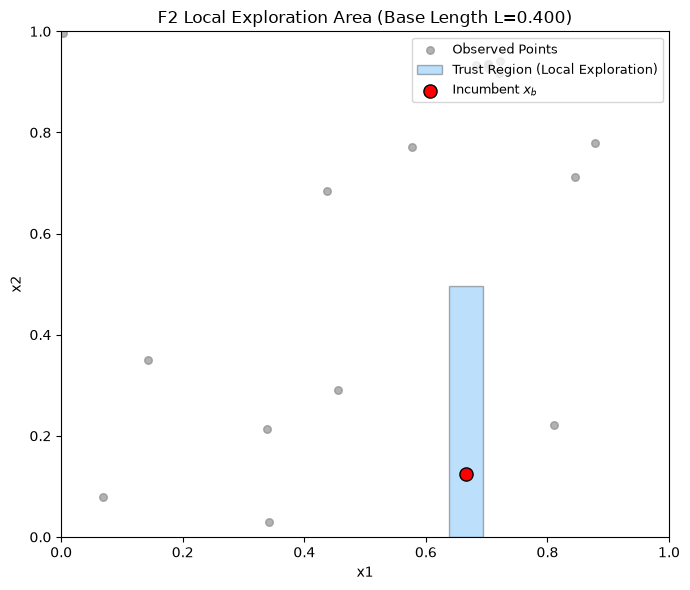

In [412]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Target Function 1
fn = 2

# Extract TuRBO state bounds and incumbent for F1
lo = TURBO_STATE[fn]["lo"]
hi = TURBO_STATE[fn]["hi"]
xb = TURBO_STATE[fn]["xb"]
L = TURBO_STATE[fn]["length"]

# Extract all observed inputs for F1
X = all_X[fn-1].values

# Initialize 2D plot
fig, ax = plt.subplots(figsize=(7, 6))

# Plot all observed points in the background
ax.scatter(X[:,0], X[:,1], color='grey', s=30, alpha=0.6, label='Observed Points', zorder=2)

# Plot the shaded trust region representing the local exploration bounds
trust_region = patches.Rectangle(
    (lo[0], lo[1]), hi[0]-lo[0], hi[1]-lo[1],
    facecolor='#2196F3', alpha=0.3, edgecolor='k', 
    zorder=1, label='Trust Region (Local Exploration)'
)
ax.add_patch(trust_region)

# Plot the incumbent point at the center of the trust region
ax.scatter([xb[0]], [xb[1]], color='red', s=90, edgecolors='k', zorder=3, label='Incumbent $x_b$')

# Format the plot area
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_title(f'F2 Local Exploration Area (Base Length L={L:.3f})')
ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

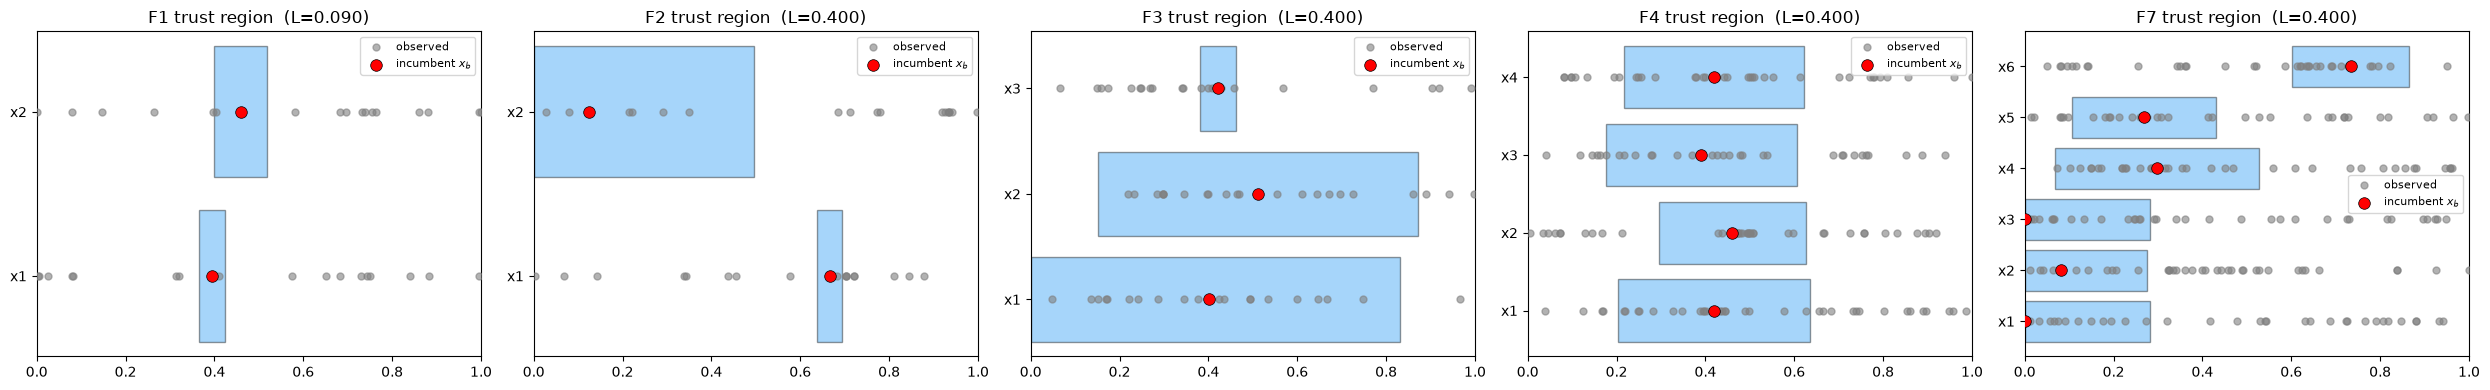

In [396]:
turbo_fns = [fn for fn in range(1,9)
             if df_best.loc[fn,'strategy'] in ('turbo','turbo_mb')]
fig, axes = plt.subplots(1, len(turbo_fns), figsize=(5*len(turbo_fns), 4))
if len(turbo_fns)==1: axes=[axes]
for ax, fn in zip(axes, turbo_fns):
    lo, hi = TURBO_STATE[fn]["lo"], TURBO_STATE[fn]["hi"]
    xb = TURBO_STATE[fn]["xb"]; nd = len(xb)
    dims = [f"x{i+1}" for i in range(nd)]
    X = all_X[fn-1].values   # all observed points for this function

    ax.barh(dims, hi-lo, left=lo, color='#2196F3', alpha=.4, edgecolor='k', zorder=1)
    for j in range(nd):
        ax.scatter(X[:, j], [dims[j]]*len(X), color='grey', s=25, alpha=.6, zorder=3,
                   label='observed' if j==0 else None)
    ax.scatter([xb[0]], [dims[0]], color='red', s=0, zorder=4)  # dummy for legend spacing
    for j in range(nd):
        ax.scatter([xb[j]], [dims[j]], color='red', s=70, zorder=5,
                   label='incumbent $x_b$' if j==0 else None, edgecolors='k', linewidths=.5)
    ax.set_xlim(0,1); ax.set_title(f'F{fn} trust region  (L={TURBO_STATE[fn]["length"]:.3f})')
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

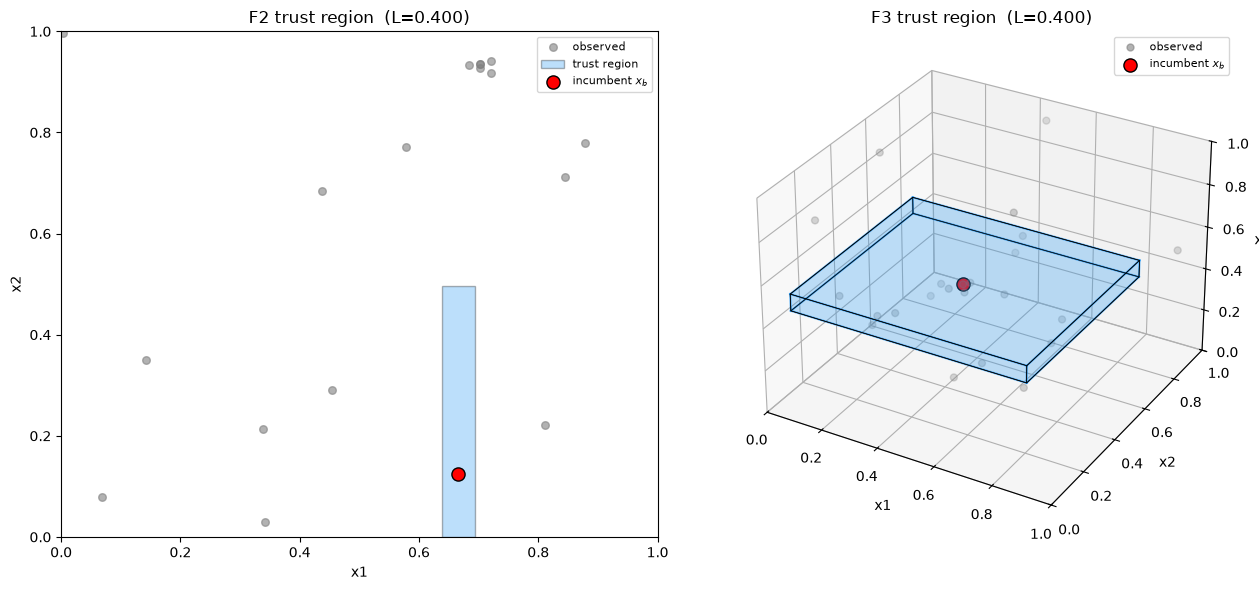

In [397]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

fig = plt.figure(figsize=(13, 6))

# --- F2: 2D ---
ax1 = fig.add_subplot(1, 2, 1)
fn = 2
lo, hi = TURBO_STATE[fn]["lo"], TURBO_STATE[fn]["hi"]
xb = TURBO_STATE[fn]["xb"]
X = all_X[fn-1].values

ax1.scatter(X[:,0], X[:,1], color='grey', s=30, alpha=.6, label='observed', zorder=2)
ax1.add_patch(plt.Rectangle((lo[0], lo[1]), hi[0]-lo[0], hi[1]-lo[1],
              facecolor='#2196F3', alpha=.3, edgecolor='k', zorder=1, label='trust region'))
ax1.scatter([xb[0]], [xb[1]], color='red', s=90, edgecolors='k', zorder=3, label='incumbent $x_b$')
ax1.set_xlim(0,1); ax1.set_ylim(0,1); ax1.set_xlabel('x1'); ax1.set_ylabel('x2')
ax1.set_title(f'F2 trust region  (L={TURBO_STATE[fn]["length"]:.3f})')
ax1.legend(fontsize=8)

# --- F3: 3D ---
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
fn = 3
lo, hi = TURBO_STATE[fn]["lo"], TURBO_STATE[fn]["hi"]
xb = TURBO_STATE[fn]["xb"]
X = all_X[fn-1].values

ax2.scatter(X[:,0], X[:,1], X[:,2], color='grey', s=25, alpha=.6, label='observed')
ax2.scatter([xb[0]], [xb[1]], [xb[2]], color='red', s=90, edgecolors='k', label='incumbent $x_b$')

# wireframe box from lo/hi corners
corners = np.array(np.meshgrid([lo[0],hi[0]], [lo[1],hi[1]], [lo[2],hi[2]])).T.reshape(-1,3)
edges = [(0,1),(0,2),(1,3),(2,3),(4,5),(4,6),(5,7),(6,7),(0,4),(1,5),(2,6),(3,7)]
# reorder corners to standard cube vertex order
c = np.array([[lo[0],lo[1],lo[2]],[hi[0],lo[1],lo[2]],[lo[0],hi[1],lo[2]],[hi[0],hi[1],lo[2]],
              [lo[0],lo[1],hi[2]],[hi[0],lo[1],hi[2]],[lo[0],hi[1],hi[2]],[hi[0],hi[1],hi[2]]])

# after the wireframe edges loop, add shaded faces:
faces = [
    [c[0],c[1],c[3],c[2]],  # bottom (z=lo)
    [c[4],c[5],c[7],c[6]],  # top (z=hi)
    [c[0],c[1],c[5],c[4]],  # front (y=lo)
    [c[2],c[3],c[7],c[6]],  # back (y=hi)
    [c[0],c[2],c[6],c[4]],  # left (x=lo)
    [c[1],c[3],c[7],c[5]],  # right (x=hi)
]
box = Poly3DCollection(faces, facecolor='#2196F3', edgecolor='k', alpha=.15, linewidths=.5)
ax2.add_collection3d(box)

for i,j in edges:
    ax2.plot(*zip(c[i], c[j]), color='#2196F3', alpha=.7)

ax2.set_xlim(0,1); ax2.set_ylim(0,1); ax2.set_zlim(0,1)
ax2.set_xlabel('x1'); ax2.set_ylabel('x2'); ax2.set_zlabel('x3')
ax2.set_title(f'F3 trust region  (L={TURBO_STATE[fn]["length"]:.3f})')
ax2.legend(fontsize=8)

plt.tight_layout(); plt.show()

## Dimension importance — multi-method diagnostic
Four normalised views per dimension: **ard** (GP lengthscale), **gp_grad** (GP posterior-mean sensitivity), **rf_perm** (RF permutation importance), **shap** (SHAP on RF). Because ard≈gp_grad (r=0.98) and rf_perm≈shap (r=0.98), they collapse into two independent family scores — **gp_fam** and **rf_fam** — whose mean is the **consensus** and whose gap is **disagree**. A dim is **frozen** only when its ARD lengthscale is at the ceiling *and* both families agree it is inert; a high `disagree` flags an interaction candidate (never frozen).

In [398]:
for fn in range(1,9):
    d = diagnostics[fn]
    print(f"\nF{fn}  (LOO R^2 = {d['loo_r2']:+.3f})")
    print(d['importance'].to_string(index=False))


F1  (LOO R^2 = -0.122)
dim   ard  gp_grad  rf_perm  shap  gp_fam  rf_fam  consensus  disagree  lengthscale  saturated  frozen
 x1 1.000    1.000    1.000   NaN   1.000   1.000      1.000     0.000         0.05      False   False
 x2 0.507    0.482    0.381   NaN   0.495   0.381      0.438     0.114         0.10      False   False

F2  (LOO R^2 = +0.810)
dim   ard  gp_grad  rf_perm  shap  gp_fam  rf_fam  consensus  disagree  lengthscale  saturated  frozen
 x1 1.000      1.0    1.000   NaN   1.000   1.000      1.000     0.000         0.07      False   False
 x2 0.004      0.0    0.208   NaN   0.002   0.208      0.105     0.206        20.00       True   False

F3  (LOO R^2 = +0.220)
dim   ard  gp_grad  rf_perm  shap  gp_fam  rf_fam  consensus  disagree  lengthscale  saturated  frozen
 x1 0.005    0.000    0.030   NaN   0.002   0.030      0.016     0.027        20.00       True    True
 x2 0.110    0.088    0.109   NaN   0.099   0.109      0.104     0.009         0.84      False   False
 

    ### Individual metrics per dimension (grouped bars)
The raw four scores side by side, so you can read each dimension directly rather than through the collapsed consensus. Blues = GP family (ard, gp_grad); greens = RF family (rf_perm, shap). Where the blue pair and the green pair diverge, that dimension is an interaction candidate.

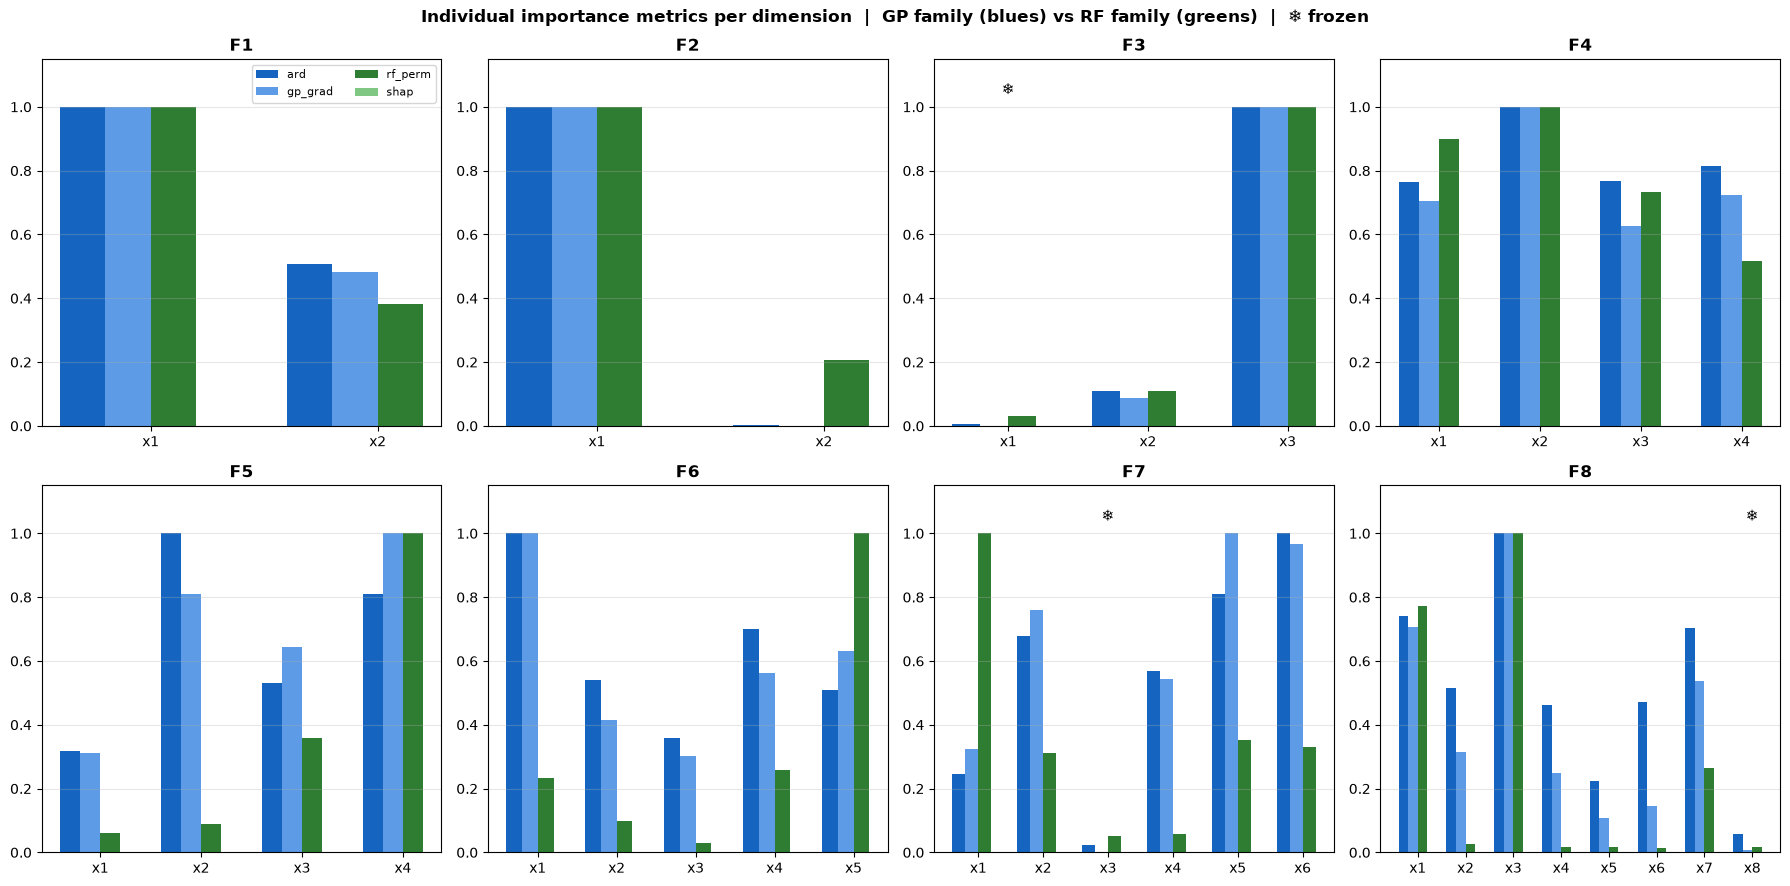

In [399]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9)); axes = axes.ravel()
metrics = ['ard','gp_grad','rf_perm','shap']
mc = {'ard':'#1565C0','gp_grad':'#5E9BE6','rf_perm':'#2E7D32','shap':'#81C784'}
for fn in range(1,9):
    ax=axes[fn-1]; imp=diagnostics[fn]['importance']; dims=imp['dim'].tolist()
    x=np.arange(len(dims)); w=0.2
    for k,m in enumerate(metrics):
        ax.bar(x+(k-1.5)*w, imp[m].values, w, label=m, color=mc[m])
    for j,fr in enumerate(imp['frozen'].values):
        if fr: ax.text(j,1.04,'❄',ha='center',fontsize=11)
    ax.set_xticks(x); ax.set_xticklabels(dims); ax.set_ylim(0,1.15)
    ax.set_title(f'F{fn}',fontweight='bold'); ax.grid(axis='y',alpha=.3)
    if fn==1: ax.legend(fontsize=8, ncol=2)
fig.suptitle('Individual importance metrics per dimension  |  GP family (blues) vs RF family (greens)  |  ❄ frozen',fontweight='bold')
plt.tight_layout(); plt.show()

### Family-aware heatmaps — GP-family · RF-family · disagreement

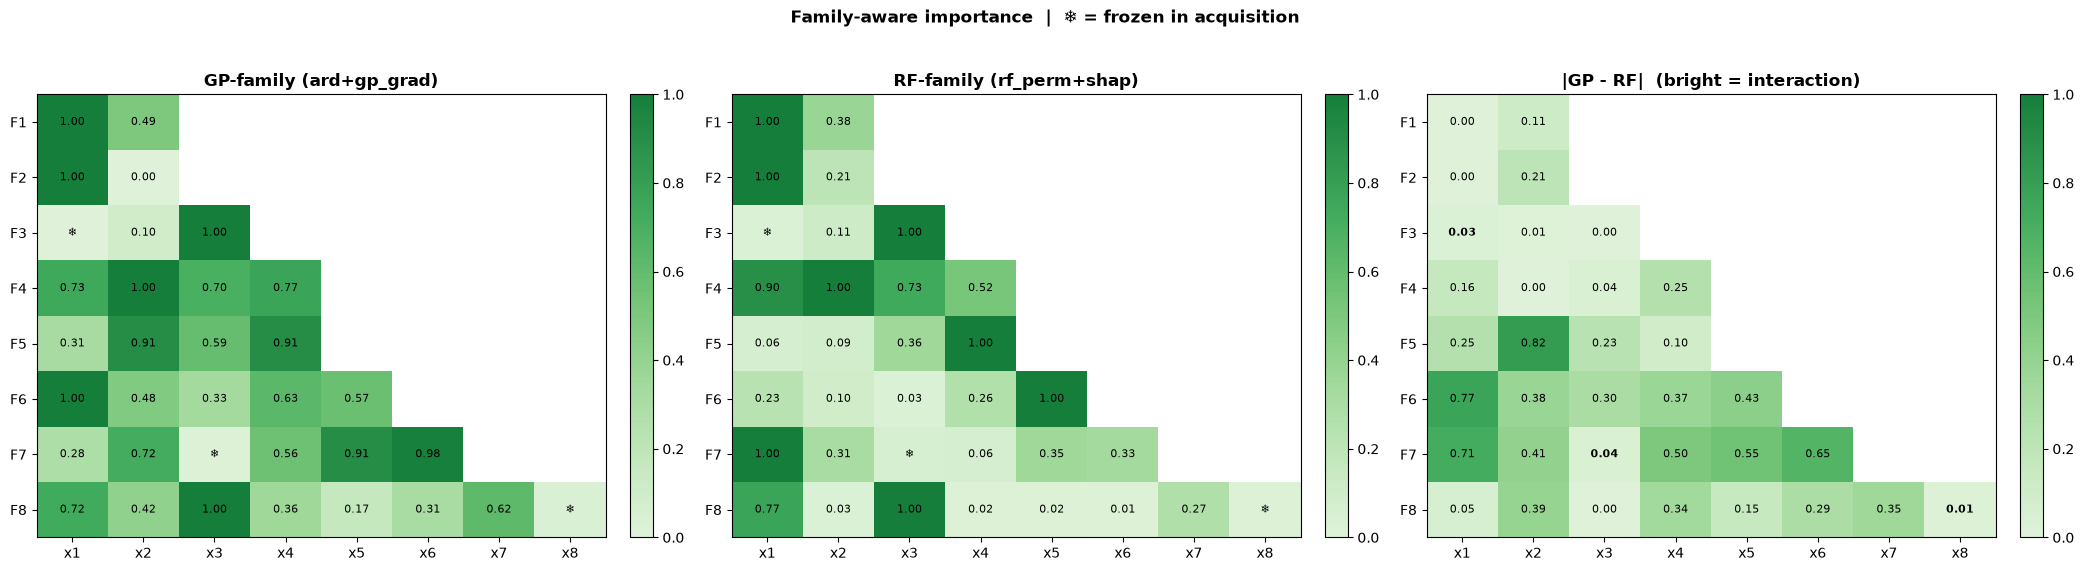

In [400]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# 1. Clear any cached figure properties completely
plt.close('all') 
fig, axes = plt.subplots(1, 3, figsize=(21, 5.5))

# 2. Re-create the light green colormap fresh
truncated_greens = mcolors.LinearSegmentedColormap.from_list(
    'light_greens', plt.cm.Greens(np.linspace(0.15, 0.8, 256))
)

# 3. Explicitly pass the custom colormap object
panels = [('gp_fam','GP-family (ard+gp_grad)', truncated_greens),
          ('rf_fam','RF-family (rf_perm+shap)', truncated_greens),
          ('disagree','|GP - RF|  (bright = interaction)', truncated_greens)]

for ax,(key,title,cmap) in zip(axes, panels):
    M=np.full((8,8),np.nan)
    for fn in range(1,9):
        imp=diagnostics[fn]['importance']; M[fn-1,:len(imp)]=imp[key].values
    
    # 4. Map the data directly to the new colormap limits
    im=ax.imshow(np.ma.masked_invalid(M), cmap=cmap, aspect='auto', vmin=0, vmax=1)
    
    for fn in range(1,9):
        imp=diagnostics[fn]['importance']
        for j in range(len(imp)):
            fr=imp['frozen'].iloc[j]
            lab=('❄' if (fr and key!='disagree') else f'{M[fn-1,j]:.2f}')
            ax.text(j,fn-1,lab,ha='center',va='center',fontsize=8,
                    color='black',
                    fontweight='bold' if fr else 'normal')
                    
    ax.set_xticks(range(8)); ax.set_xticklabels([f'x{i+1}' for i in range(8)])
    ax.set_yticks(range(8)); ax.set_yticklabels([f'F{i+1}' for i in range(8)])
    ax.set_title(title,fontweight='bold')
    
    # 5. Generate a fresh colorbar bound to the updated image object
    fig.colorbar(im, ax=ax, fraction=.046, pad=.04)

fig.suptitle('Family-aware importance  |  ❄ = frozen in acquisition', fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()


### GP-family vs RF-family scatter (per function)
Each point is a dimension. On the diagonal = the two model families agree. Off-diagonal (red, |diff|>0.5) = they conflict — the fingerprint of an interaction effect or structure one family misses. These dims are deliberately never frozen.

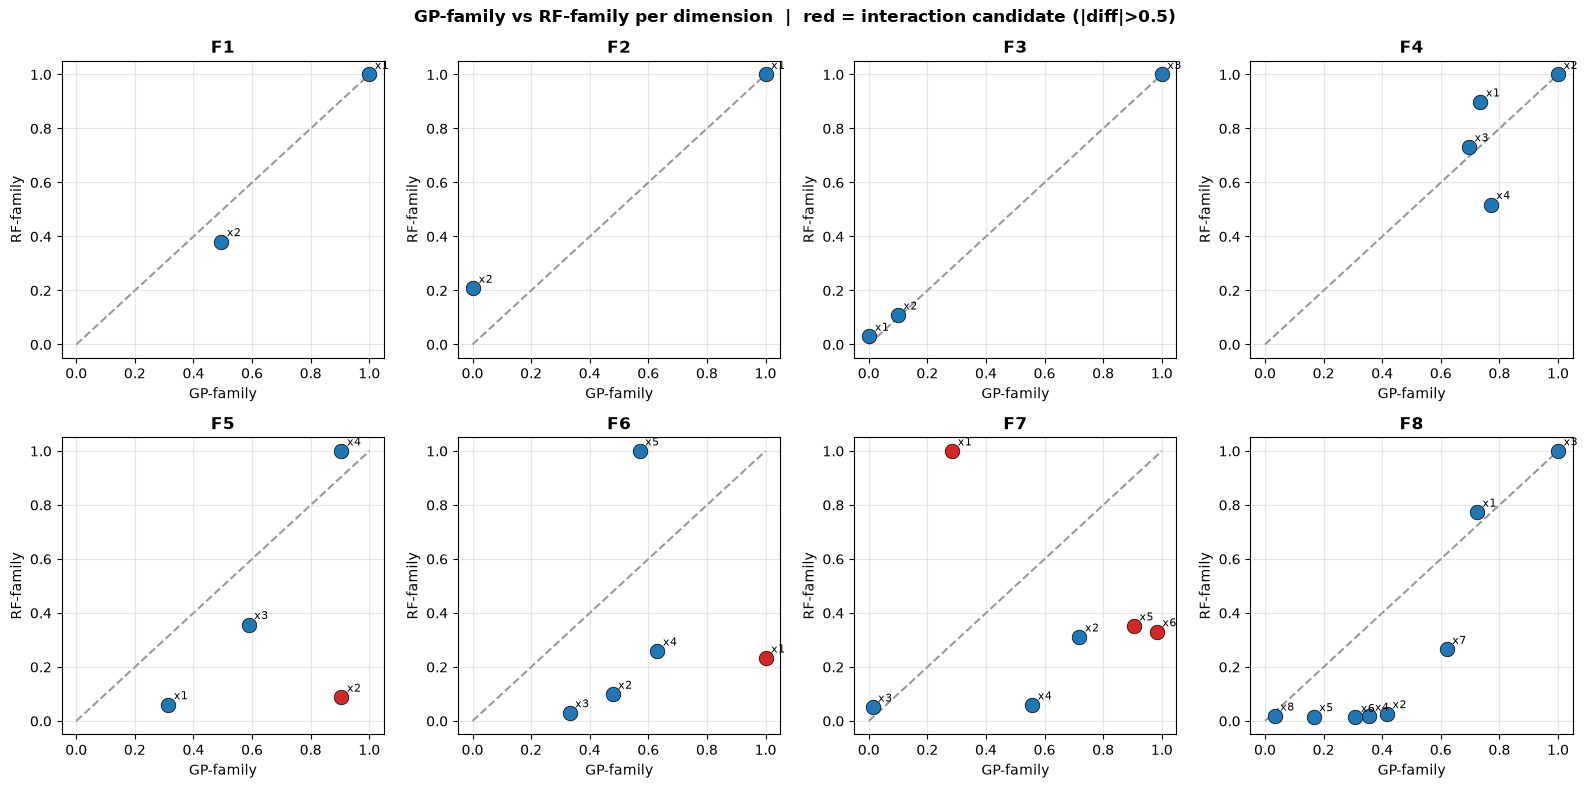

In [401]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8)); axes=axes.ravel()
for fn in range(1,9):
    ax=axes[fn-1]; imp=diagnostics[fn]['importance']
    ax.plot([0,1],[0,1],'k--',alpha=.4,zorder=1)
    for _,r in imp.iterrows():
        amb=r['disagree']>0.5
        ax.scatter(r['gp_fam'],r['rf_fam'],s=110,zorder=3,
                   c='#d62728' if amb else '#1f77b4',edgecolors='k',linewidths=.5)
        ax.annotate(r['dim'],(r['gp_fam'],r['rf_fam']),fontsize=8,
                    xytext=(4,4),textcoords='offset points')
    ax.set_xlim(-.05,1.05); ax.set_ylim(-.05,1.05)
    ax.set_xlabel('GP-family'); ax.set_ylabel('RF-family')
    ax.set_title(f'F{fn}',fontweight='bold'); ax.grid(alpha=.3)
fig.suptitle('GP-family vs RF-family per dimension  |  red = interaction candidate (|diff|>0.5)',fontweight='bold')
plt.tight_layout(); plt.show()

## Leave-one-out CV — predicted vs true (the trust gate, visualised)
Each point is one held-out observation. Tight to the dashed line = trustworthy surrogate. Red title = fails the gate (R² < 0.30) → routed to TuRBO/explore rather than global EI. Values are in the space the GP models (raw here, since no warp is active).

In [402]:
print(diagnostics[1].keys())

dict_keys(['loo_r2', 'loo_r2_before', 'loo_preds_raw', 'loo_true_raw', 'importance', 'saturation'])


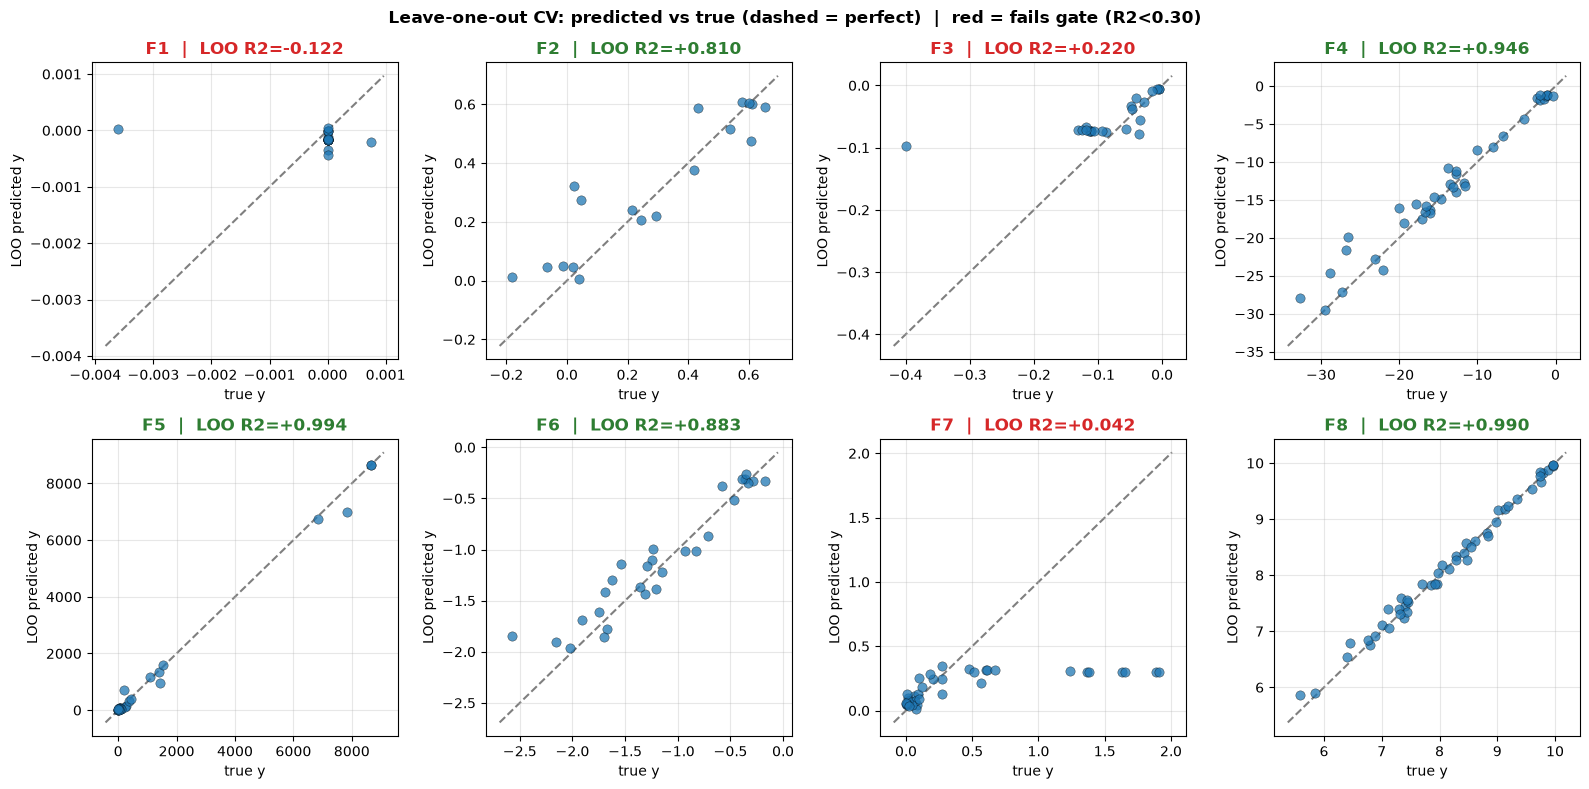

In [403]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8)); axes=axes.ravel()
for fn in range(1,9):
    ax=axes[fn-1]; d=diagnostics[fn]
    yt=np.asarray(d['loo_true_raw']); yp=np.asarray(d['loo_preds_raw'])
    lo=min(yt.min(),yp.min()); hi=max(yt.max(),yp.max()); pad=0.05*(hi-lo)+1e-9
    ax.plot([lo-pad,hi+pad],[lo-pad,hi+pad],'k--',alpha=.5,zorder=1)
    ax.scatter(yt,yp,s=45,alpha=.75,edgecolors='k',linewidths=.3,c='#1f77b4',zorder=3)
    r2=d['loo_r2']; col='#2E7D32' if r2>=.3 else '#d62728'
    ax.set_title(f'F{fn}  |  LOO R2={r2:+.3f}',fontweight='bold',color=col)
    ax.set_xlabel('true y'); ax.set_ylabel('LOO predicted y'); ax.grid(alpha=.3)
fig.suptitle('Leave-one-out CV: predicted vs true (dashed = perfect)  |  red = fails gate (R2<0.30)',fontweight='bold')
plt.tight_layout(); plt.show()

## Acquisition comparison (predicted y per acquisition)

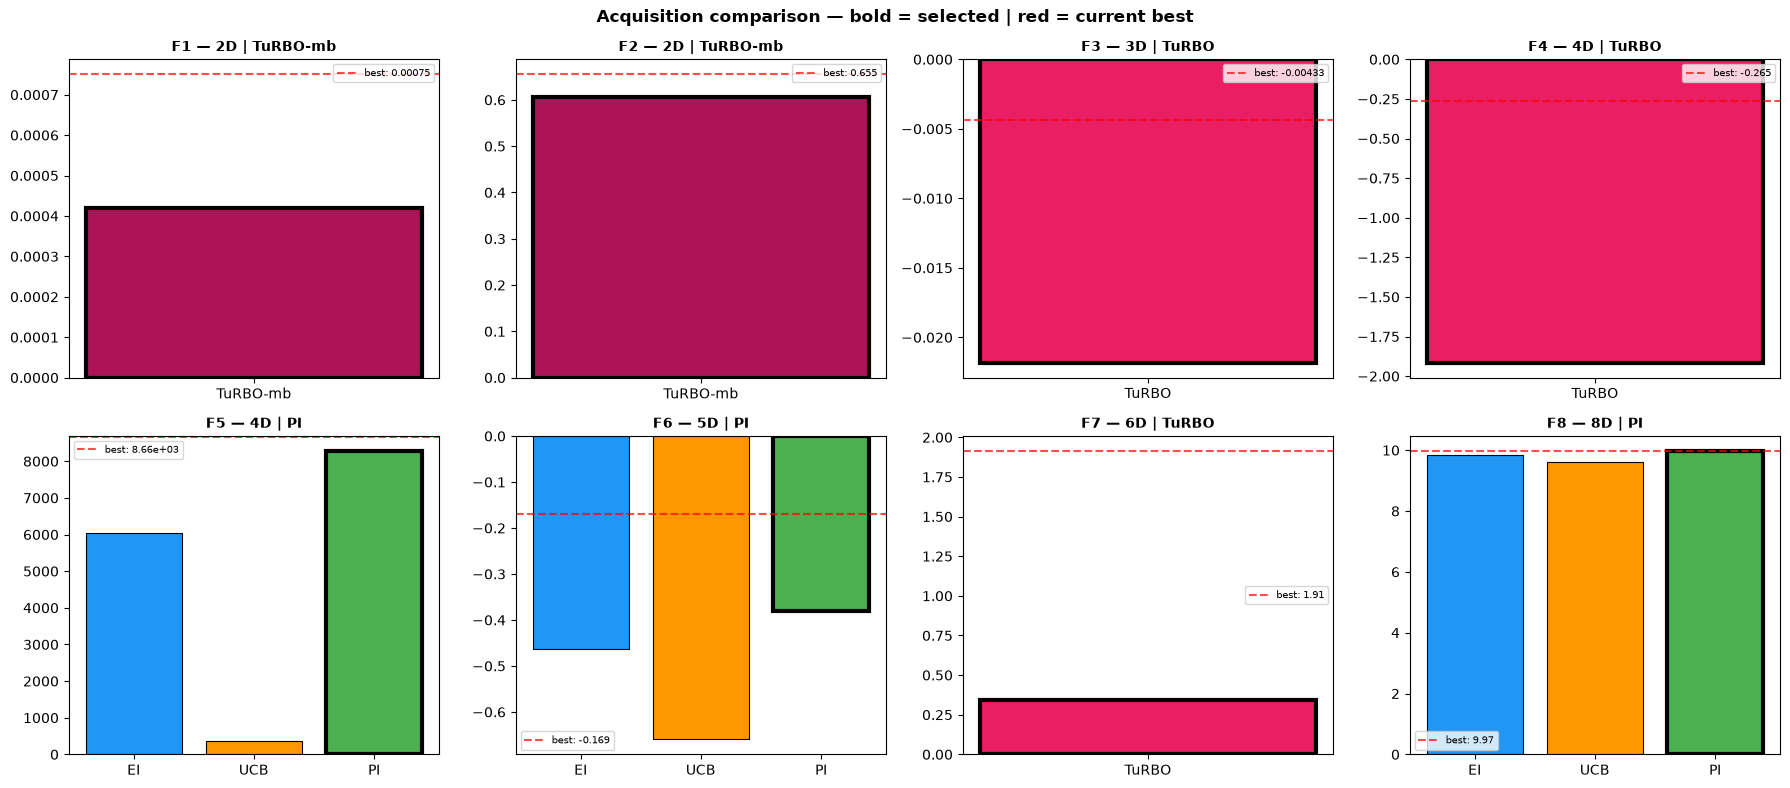

In [404]:
colours = {'EI':'#2196F3','UCB':'#FF9800','PI':'#4CAF50','TS':'#9C27B0',
           'MD':'#795548','TuRBO':'#E91E63',
           'TuRBO-mb':'#AD1457','EI-needle':'#00838F'}
fig, axes = plt.subplots(2,4,figsize=(18,8)); axes=axes.flatten()
for fn in range(1,9):
    ax=axes[fn-1]; g=df_all[df_all['function']==fn]
    winner=df_best.loc[fn,'acquisition']; yc=df_best.loc[fn,'y_max_so_far']
    names=g['acquisition'].tolist(); preds=g['predicted_y'].tolist()
    ax.bar(names, preds, color=[colours.get(a,'grey') for a in names],
           edgecolor='black', linewidth=[3 if a==winner else 0.8 for a in names])
    ax.axhline(yc, color='red', ls='--', alpha=.7, label=f'best: {yc:.3g}')
    ax.set_title(f'F{fn} — {int(g["dimensions"].iloc[0])}D | {winner}', fontsize=10, fontweight='bold')
    ax.legend(fontsize=7)
fig.suptitle('Acquisition comparison — bold = selected | red = current best', fontweight='bold')
plt.tight_layout(); plt.show()

## Marginal plots (x_i vs y)

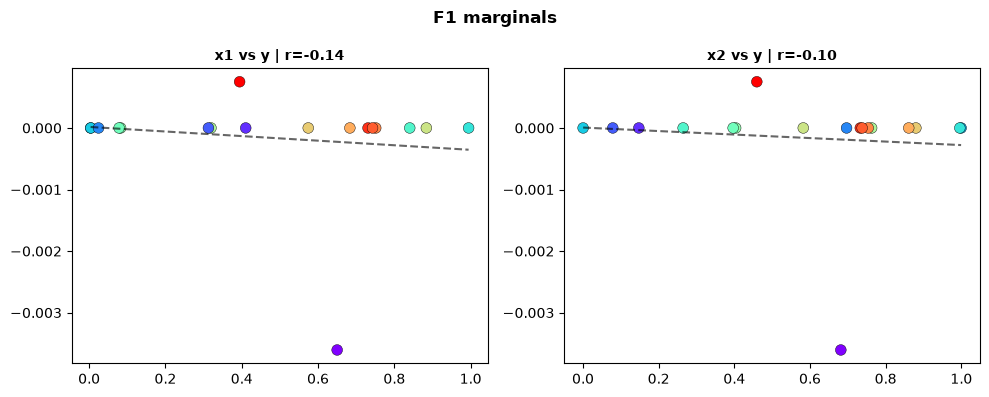

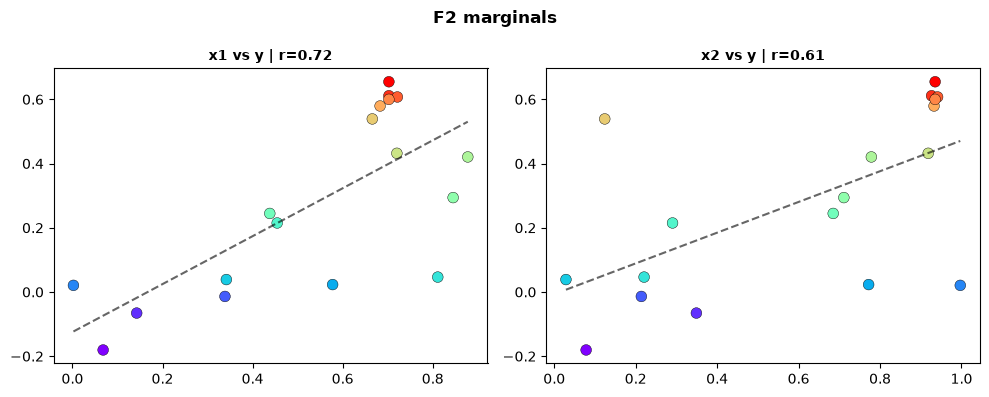

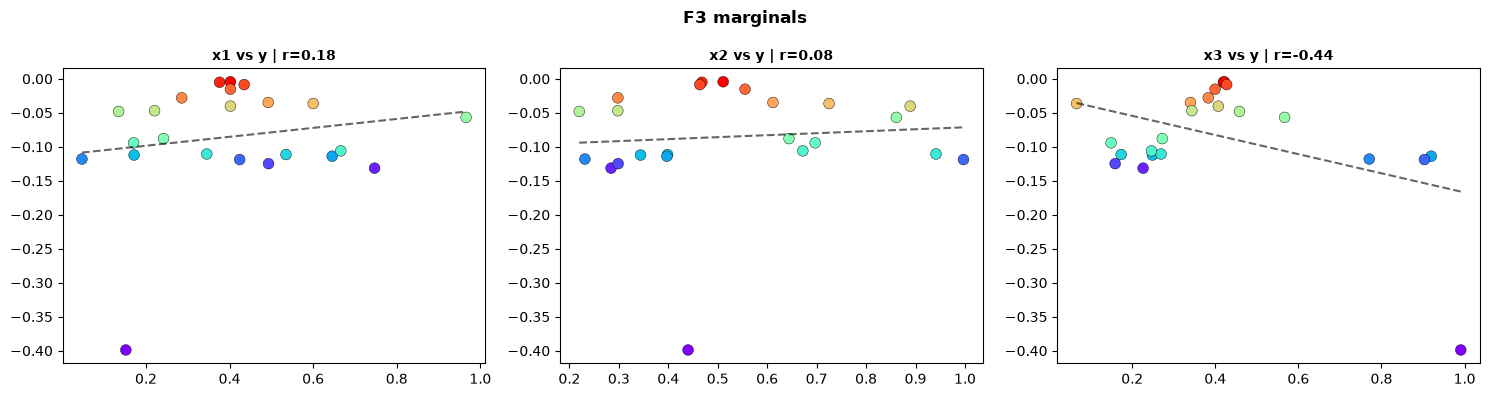

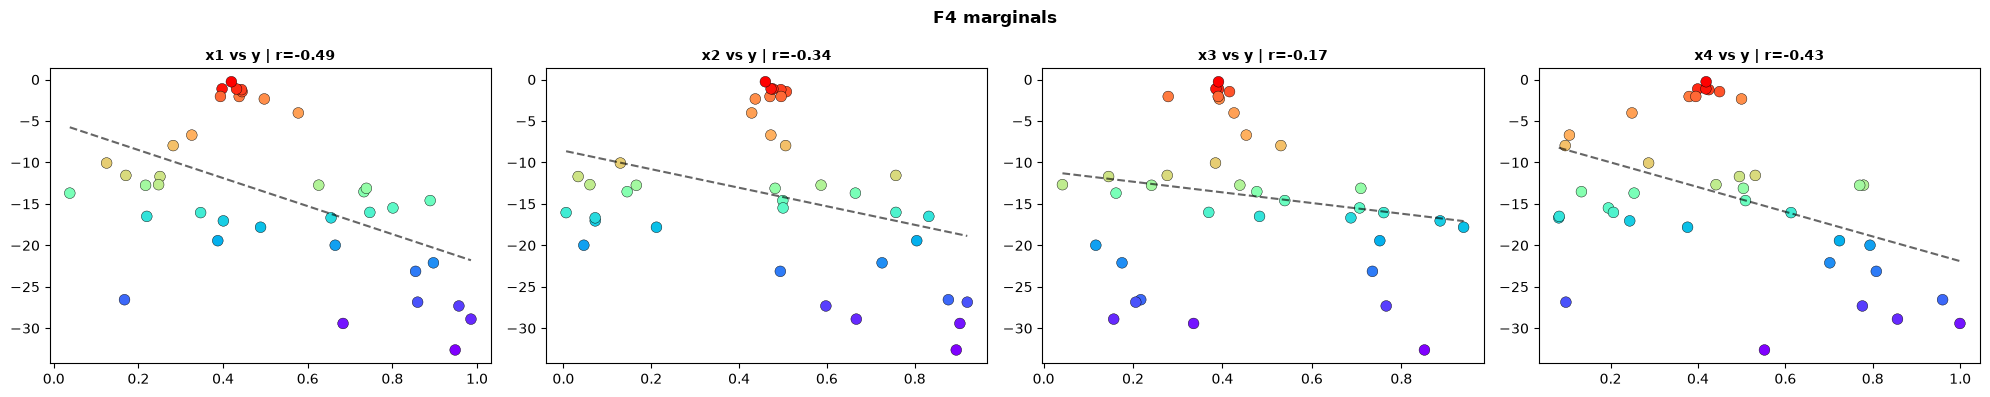

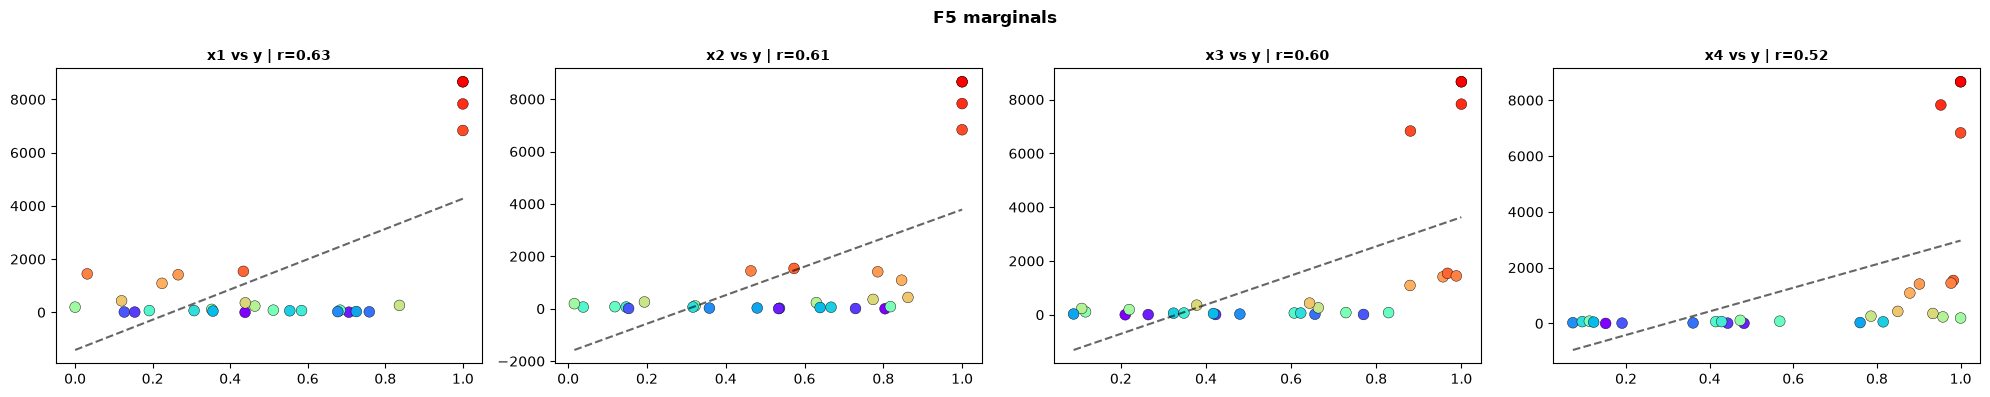

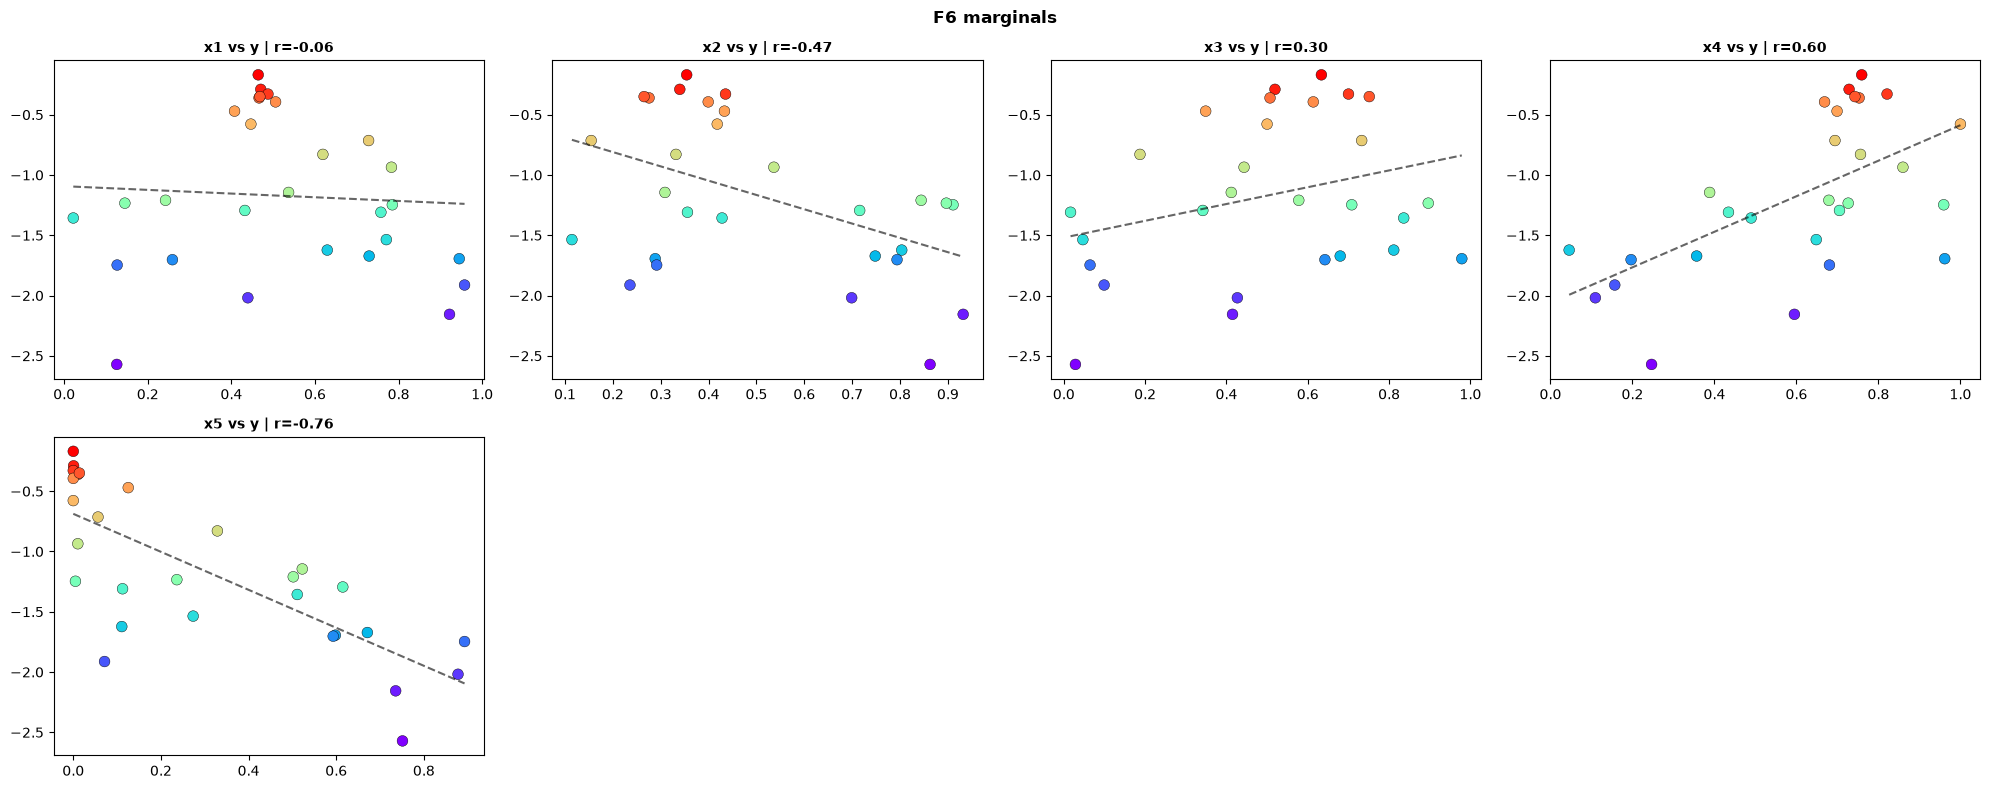

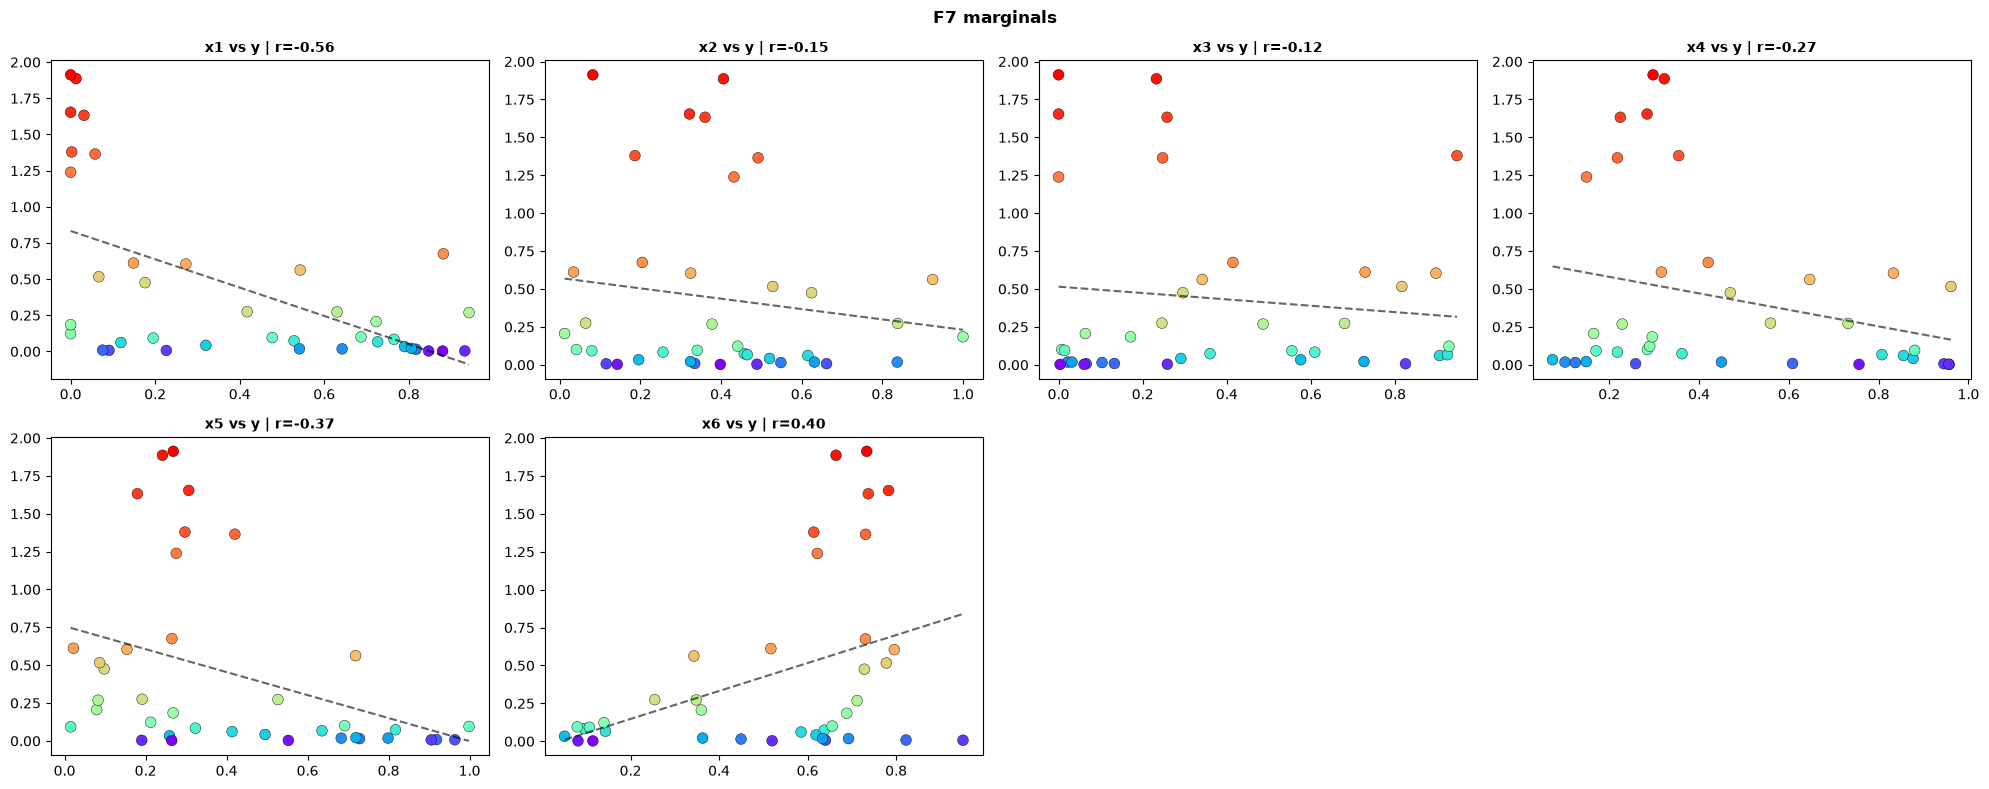

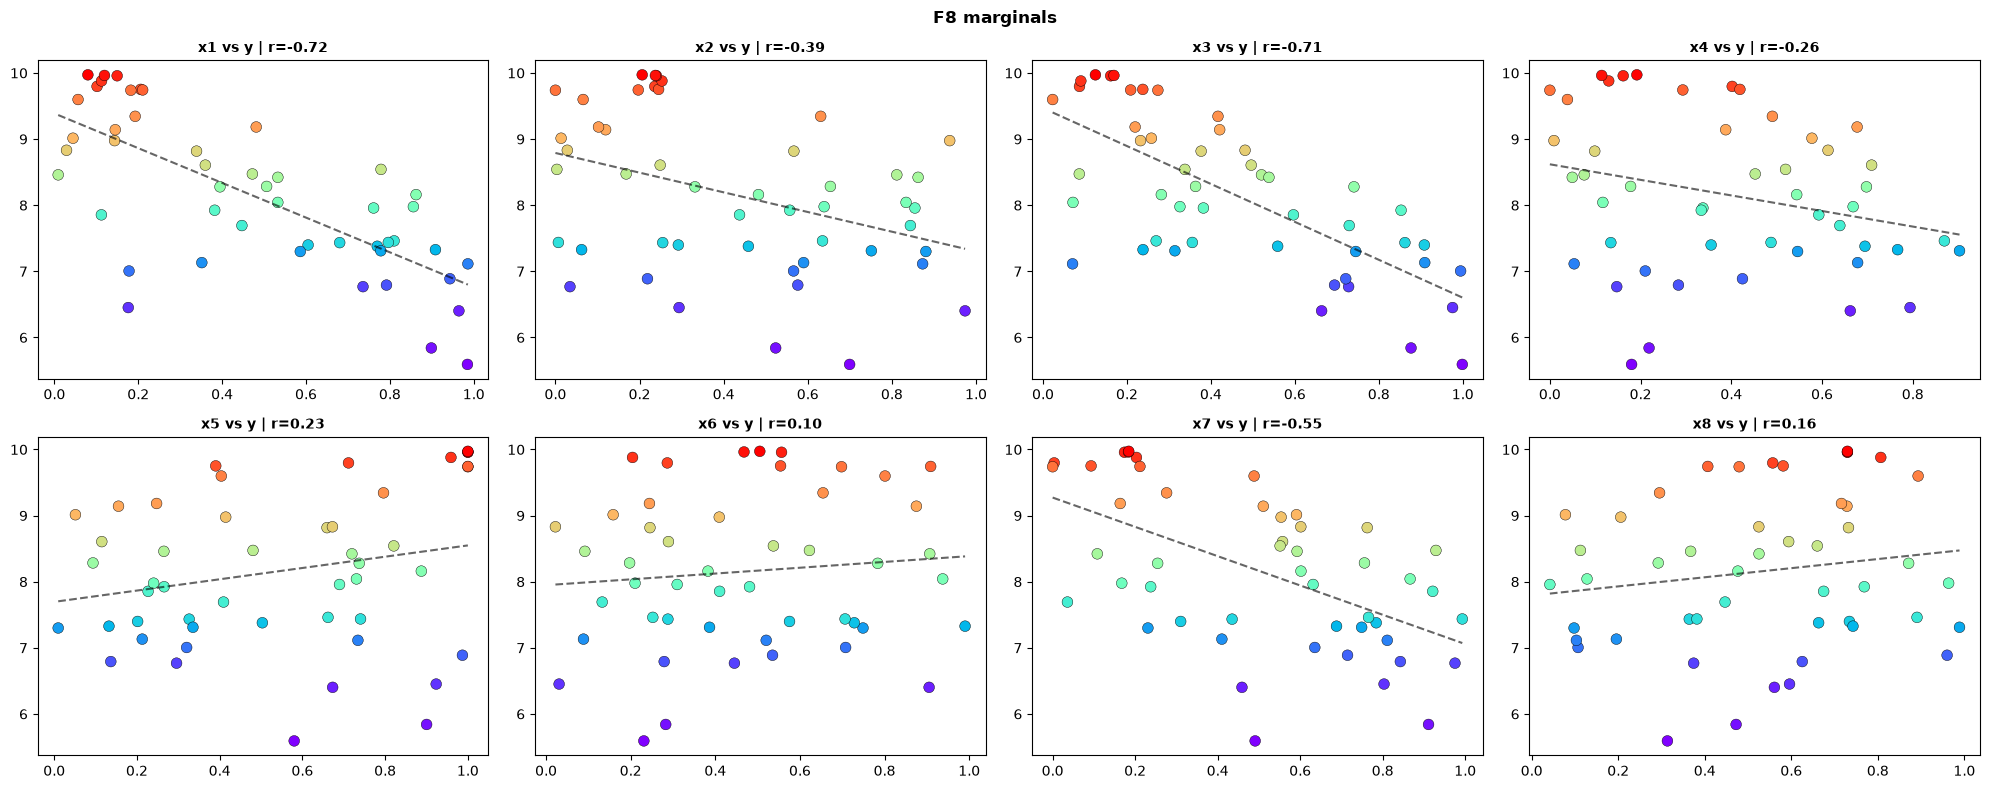

In [405]:
def plot_marginals(fn):
    X=all_X[fn-1]; y=all_y[fn-1]; nd=X.shape[1]
    nc=min(4,nd); nr=int(np.ceil(nd/nc))
    fig,axes=plt.subplots(nr,nc,figsize=(5*nc,4*nr),squeeze=False)
    yr=y.rank(pct=True)
    for i,c in enumerate(X.columns):
        ax=axes[i//nc][i%nc]
        ax.scatter(X[c], y, c=yr, cmap='rainbow', s=60, edgecolors='k', linewidths=.3)
        z=np.polyfit(X[c],y,1); xl=np.linspace(X[c].min(),X[c].max(),50)
        ax.plot(xl,np.poly1d(z)(xl),'k--',alpha=.6)
        ax.set_title(f'{c} vs y | r={X[c].corr(y):.2f}', fontsize=10, fontweight='bold')
    for k in range(nd,nr*nc): axes[k//nc][k%nc].axis('off')
    fig.suptitle(f'F{fn} marginals', fontweight='bold'); plt.tight_layout(); plt.show()
for fn in range(1,9): plot_marginals(fn)

## ARD lengthscale heatmap (WhiteKernel-aware via `matern_ls`)

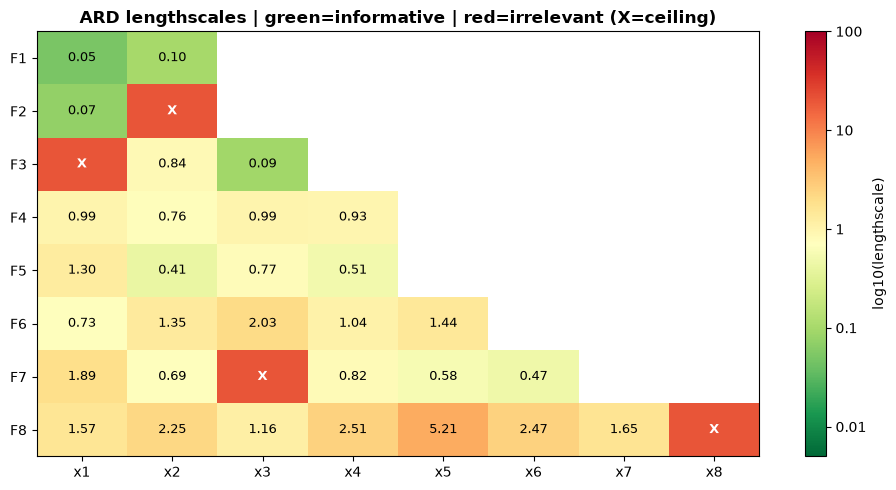

In [406]:
rows=[]
for fn in range(1,9):
    ls=matern_ls(gps[fn]); r={'function':fn}
    for c,l in zip(all_X[fn-1].columns, ls): r[c]=round(float(l),4)
    rows.append(r)
df_ls=pd.DataFrame(rows).set_index('function')
xcols=[c for c in df_ls.columns if c.startswith('x')]
data=df_ls[xcols].values.astype(float); logd=np.log10(np.where(np.isnan(data),np.nan,data))
fig,ax=plt.subplots(figsize=(max(8,len(xcols)*1.2),5))
im=ax.imshow(np.ma.masked_invalid(logd),cmap='RdYlGn_r',aspect='auto',vmin=np.log10(.005),vmax=np.log10(100))
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        if not np.isnan(data[i,j]):
            v=data[i,j]; ax.text(j,i,'X' if v>=10 else f'{v:.2f}',ha='center',va='center',
                fontsize=9,color='white' if v>=10 else 'black',fontweight='bold' if v>=10 else 'normal')
ax.set_xticks(range(len(xcols))); ax.set_xticklabels(xcols)
ax.set_yticks(range(len(df_ls))); ax.set_yticklabels([f'F{f}' for f in df_ls.index])
ax.set_title('ARD lengthscales | green=informative | red=irrelevant (X=ceiling)',fontweight='bold')
cbar=fig.colorbar(im,ax=ax); cbar.set_ticks([np.log10(v) for v in [.01,.1,1,10,100]])
cbar.set_ticklabels(['0.01','0.1','1','10','100']); cbar.set_label('log10(lengthscale)')
plt.tight_layout(); plt.show()

## Smart scatter (2D/3D/4D projections, coloured by y, with x_next)

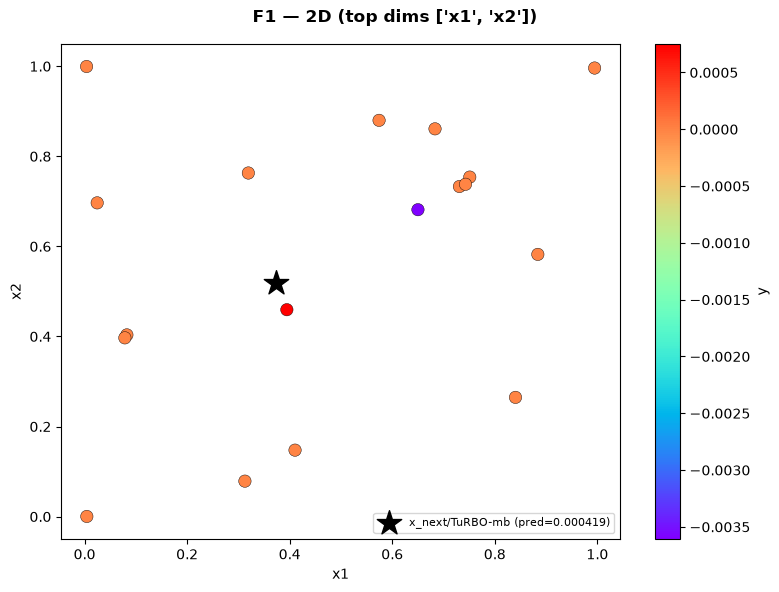

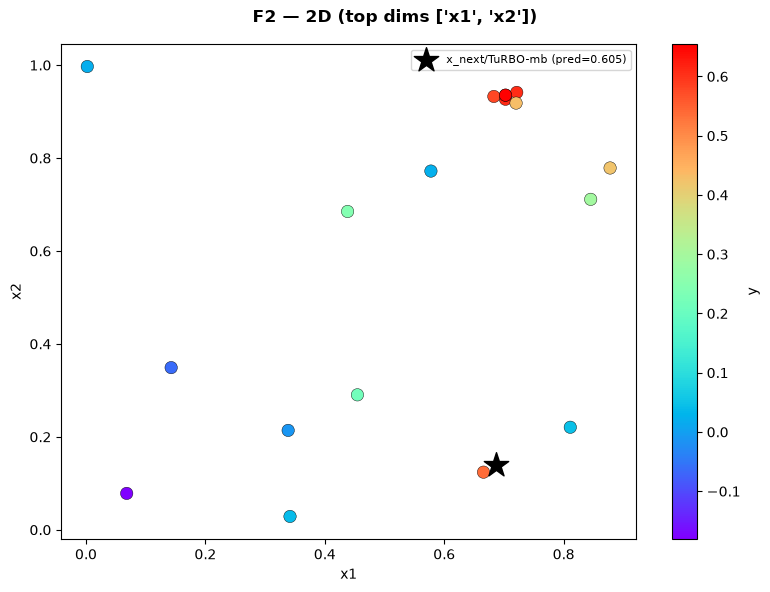

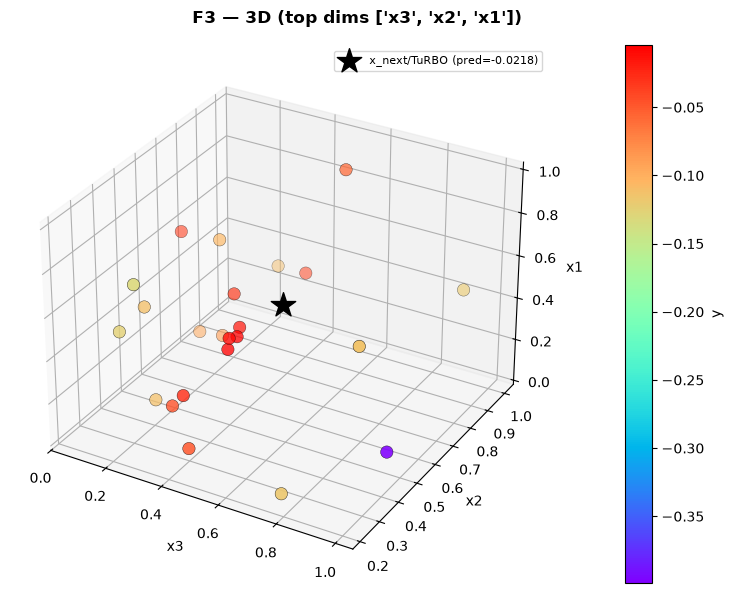

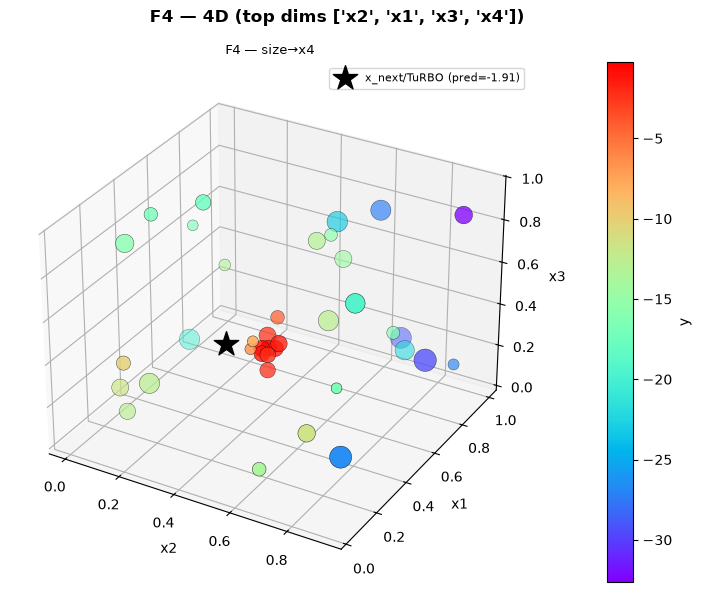

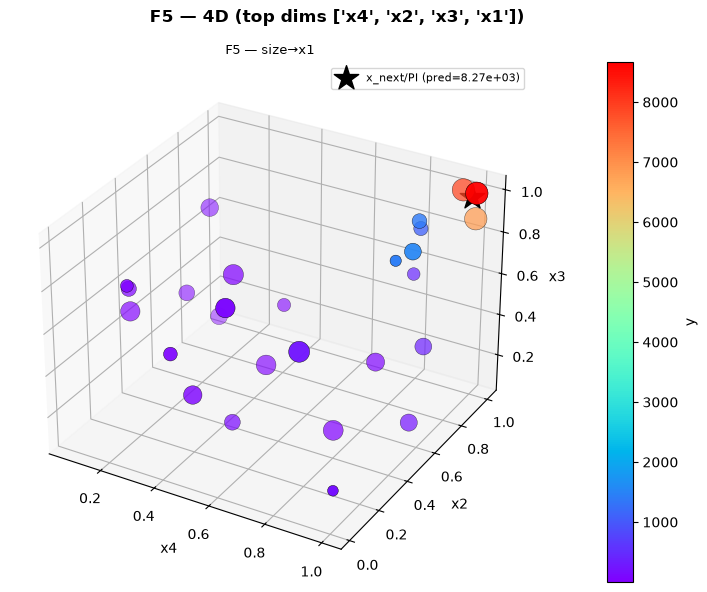

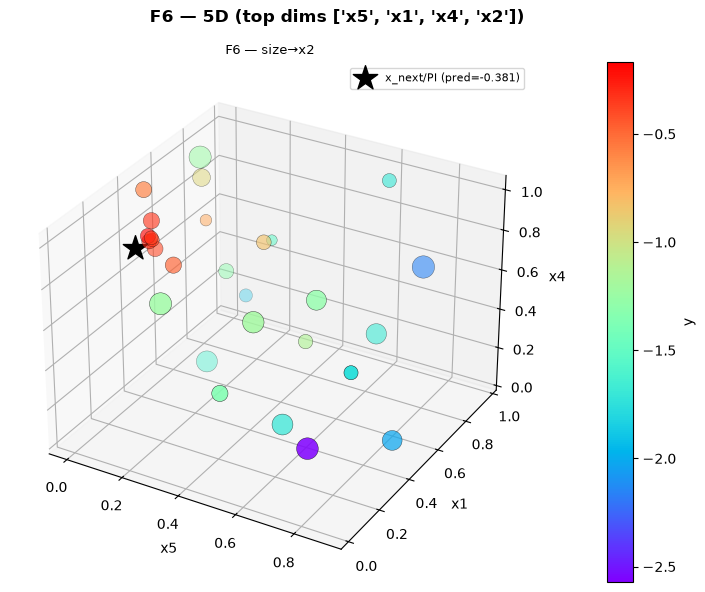

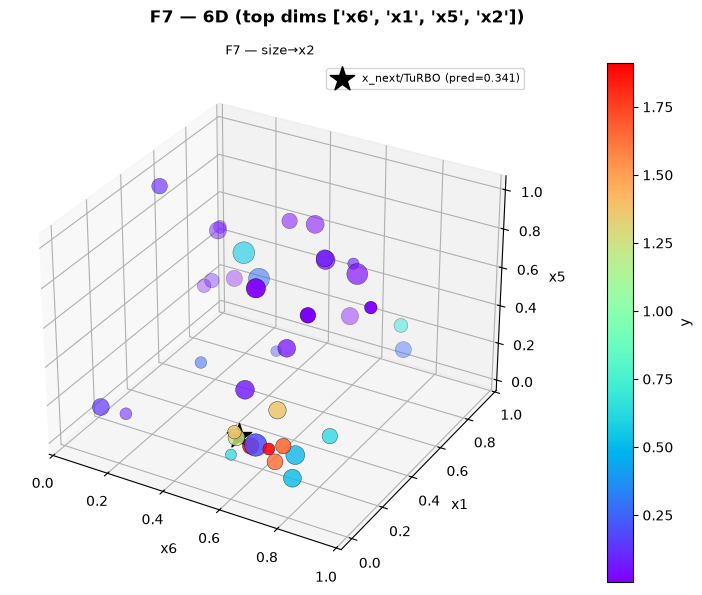

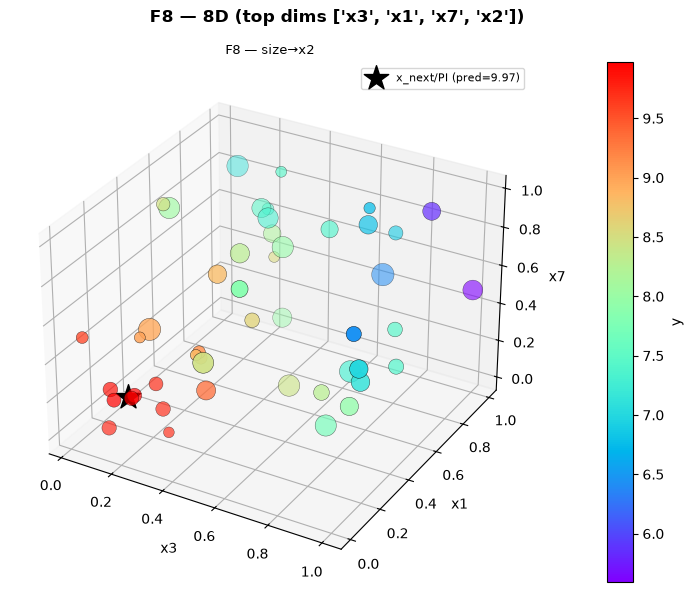

In [407]:
def plot_smart(fn):
    X=all_X[fn-1]; y=all_y[fn-1].values; nd=X.shape[1]
    dims=top_dims[fn]; pd_=dims if nd<=4 else dims[:4]; npl=len(pd_)
    norm=plt.Normalize(y.min(),y.max()); cmap=plt.cm.rainbow
    br=df_best.loc[fn]; cm_=dict(zip(X.columns.tolist(), br['x_next']))
    sc_={c:cm_[c] for c in pd_}
    lbl=f"x_next/{br['acquisition']} (pred={br['predicted_y']:.3g})"
    fig=plt.figure(figsize=(8,6))
    if npl<=2:
        d1,d2=pd_[0],pd_[1]; ax=fig.add_subplot(111)
        s=ax.scatter(X[d1],X[d2],c=y,cmap=cmap,norm=norm,s=80,edgecolors='k',linewidths=.3)
        ax.scatter(sc_[d1],sc_[d2],marker='*',s=340,color='k',zorder=6,label=lbl)
        ax.set_xlabel(d1); ax.set_ylabel(d2); fig.colorbar(s,ax=ax,label='y')
    elif npl==3:
        d1,d2,d3=pd_; ax=fig.add_subplot(111,projection='3d')
        s=ax.scatter(X[d1],X[d2],X[d3],c=y,cmap=cmap,norm=norm,s=80,edgecolors='k',linewidths=.3)
        ax.scatter(sc_[d1],sc_[d2],sc_[d3],marker='*',s=340,color='k',zorder=6,label=lbl)
        ax.set_xlabel(d1); ax.set_ylabel(d2); ax.set_zlabel(d3); fig.colorbar(s,ax=ax,label='y',pad=.1)
    else:
        d1,d2,d3,d4=pd_; ax=fig.add_subplot(111,projection='3d')
        sz=60+200*(X[d4]-X[d4].min())/(X[d4].max()-X[d4].min()+1e-9)
        s=ax.scatter(X[d1],X[d2],X[d3],c=y,cmap=cmap,norm=norm,s=sz,edgecolors='k',linewidths=.3)
        ax.scatter(sc_[d1],sc_[d2],sc_[d3],marker='*',s=340,color='k',zorder=6,label=lbl)
        ax.set_xlabel(d1); ax.set_ylabel(d2); ax.set_zlabel(d3)
        ax.set_title(f'F{fn} — size→{d4}',fontsize=9); fig.colorbar(s,ax=ax,label='y',pad=.1)
    ax.legend(fontsize=8); fig.suptitle(f'F{fn} — {nd}D (top dims {pd_})',fontweight='bold')
    plt.tight_layout(); plt.show()
for fn in range(1,9): plot_smart(fn)

## Parallel coordinates (observations + x_next)

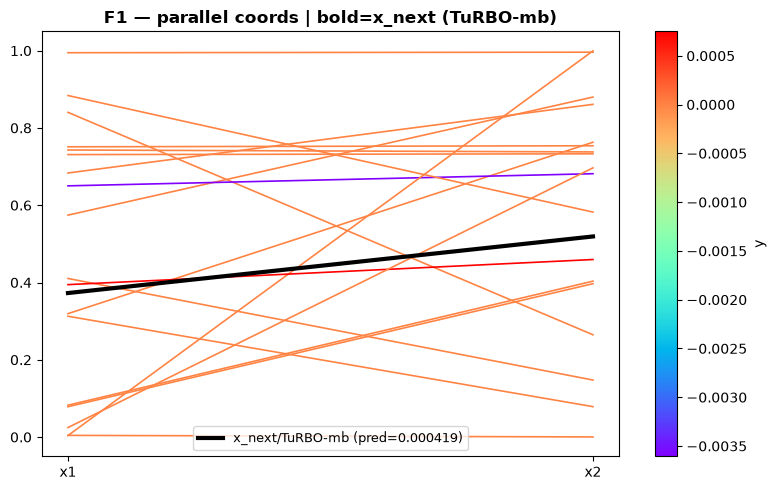

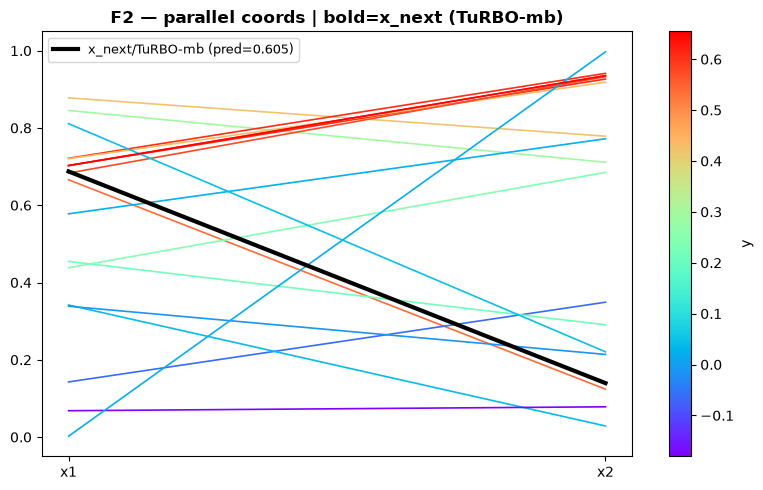

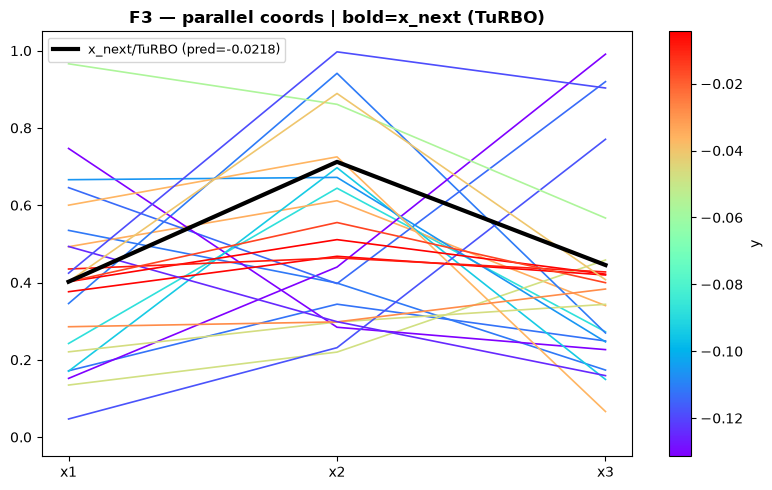

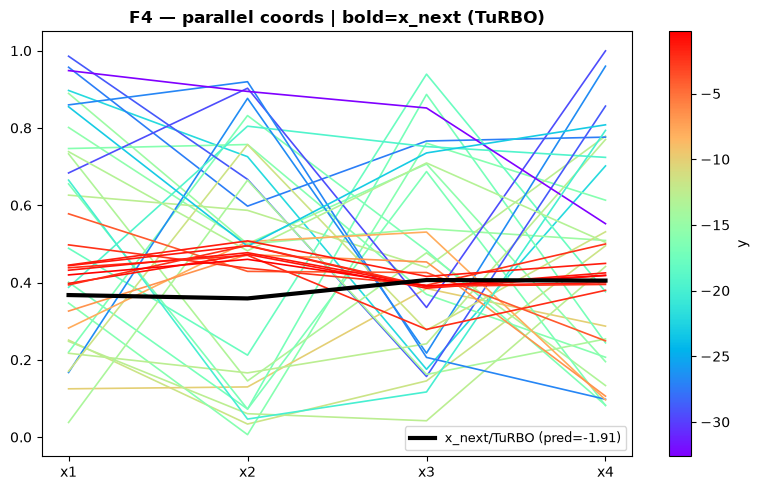

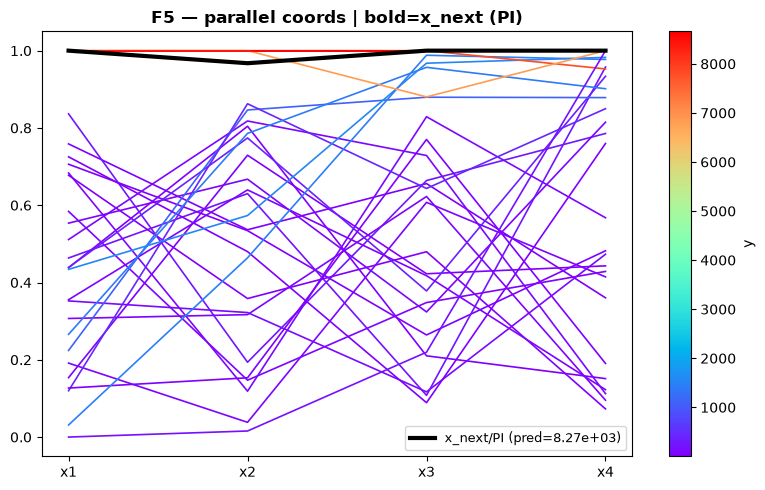

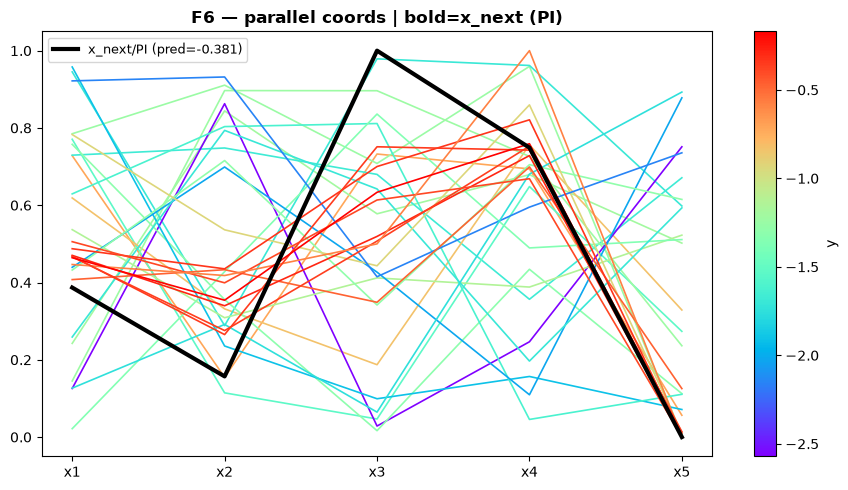

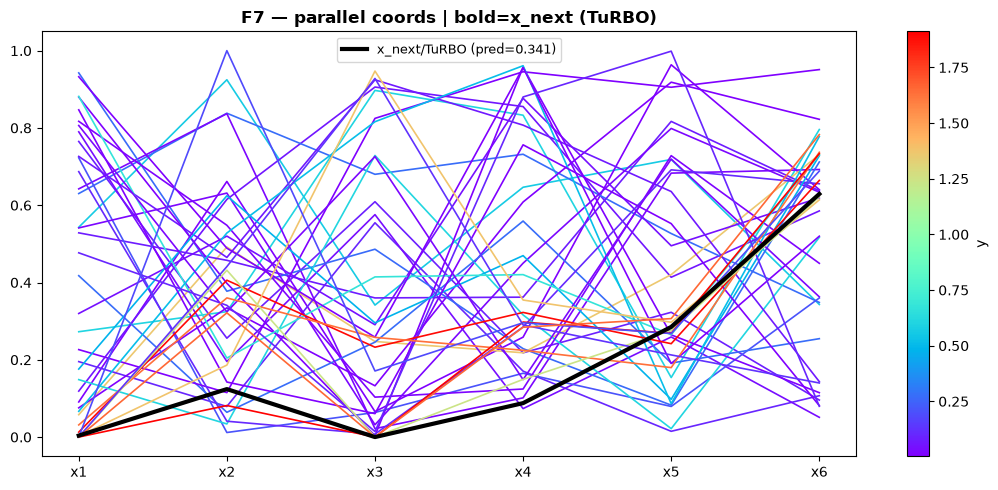

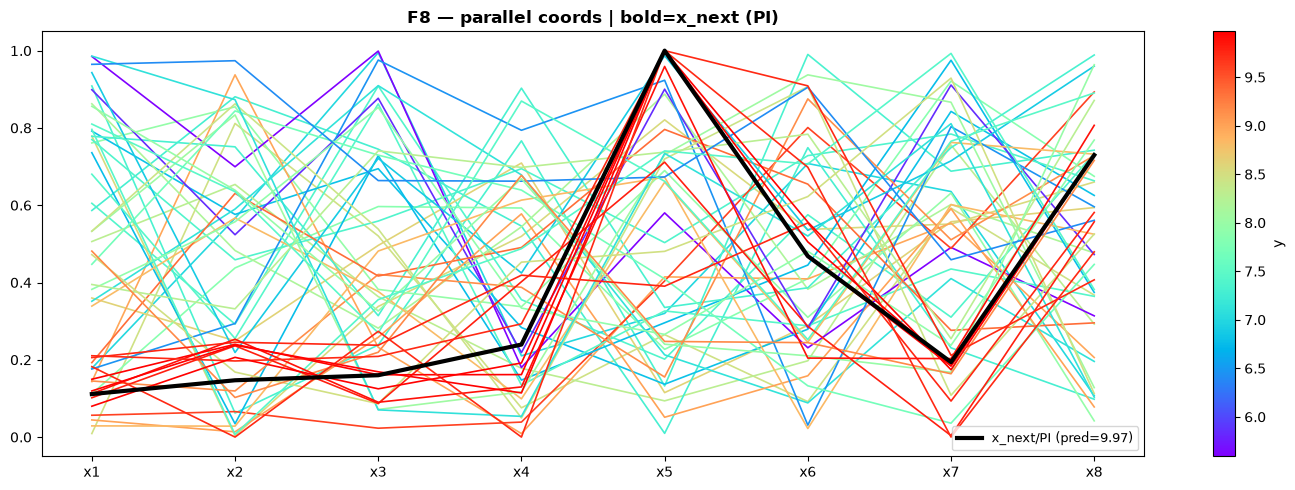

In [408]:
def plot_parallel(fn, clip_bottom=False):
    X=all_X[fn-1]; y=all_y[fn-1].values; dims=X.columns.tolist(); nd=len(dims)
    yfn = np.delete(y,np.argmin(y)) if (clip_bottom and len(y)>1) else y
    norm=mcolors.Normalize(yfn.min(),yfn.max()); cmap=cm.rainbow
    br=df_best.iloc[fn-1]; xn=np.array([float(v) for v in br['submission'].split('-')])
    fig,ax=plt.subplots(figsize=(max(8,nd*1.8),5)); xp=np.arange(nd)
    for i in range(len(X)):
        ax.plot(xp, X.iloc[i].values, color=cmap(norm(np.clip(y[i],yfn.min(),yfn.max()))), lw=1.2)
    ax.plot(xp, xn, 'k-', lw=3, zorder=5, label=f"x_next/{br['acquisition']} (pred={br['predicted_y']:.3g})")
    ax.set_xticks(xp); ax.set_xticklabels(dims); ax.set_ylim(-.05,1.05); ax.legend(fontsize=9)
    sm=cm.ScalarMappable(cmap=cmap,norm=norm); sm.set_array([]); fig.colorbar(sm,ax=ax,label='y')
    ax.set_title(f'F{fn} — parallel coords | bold=x_next ({br["acquisition"]})',fontweight='bold')
    plt.tight_layout(); plt.show()
for fn in range(1,9): plot_parallel(fn, clip_bottom=(fn==3))

## Progress tracking

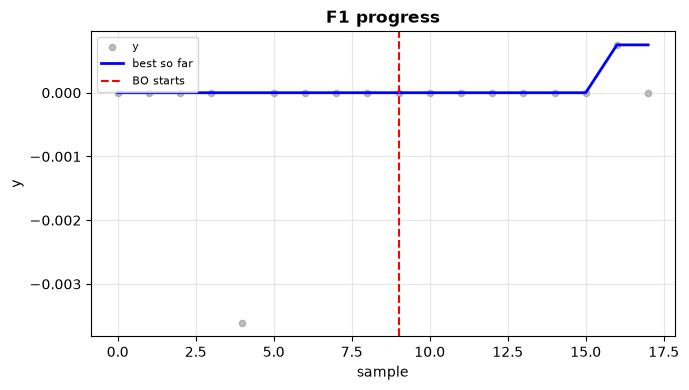

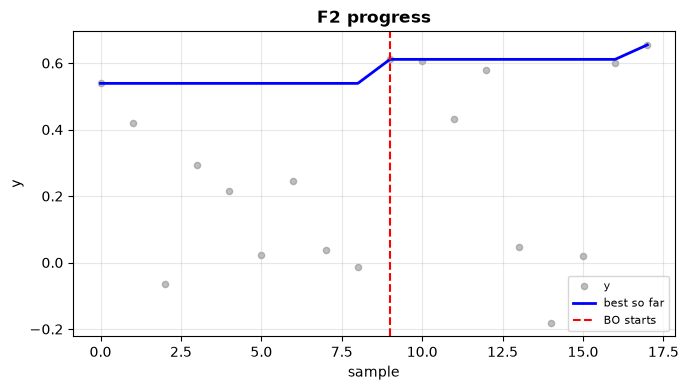

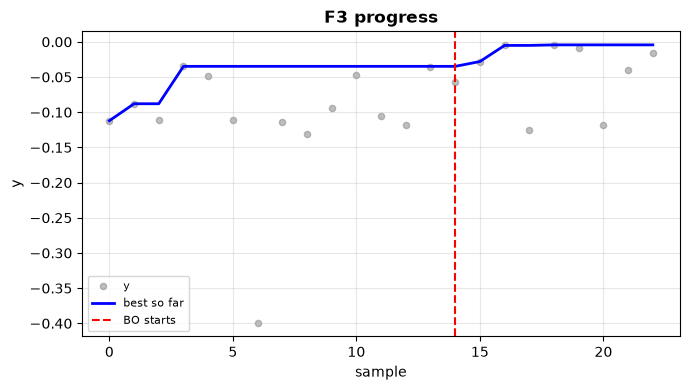

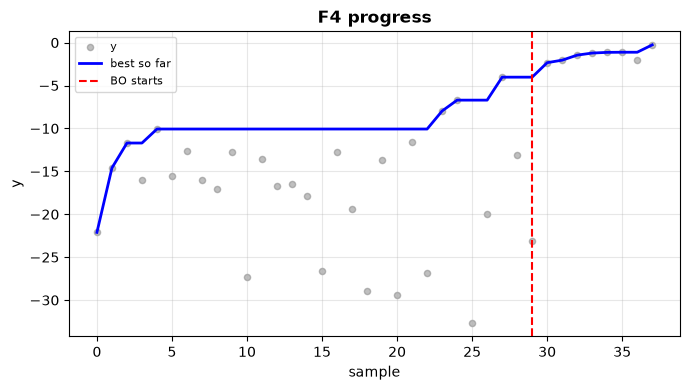

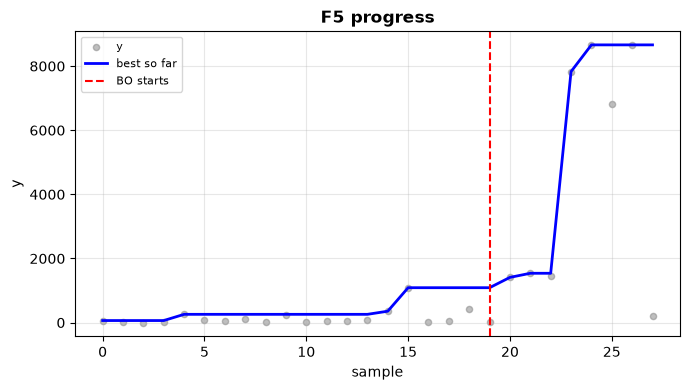

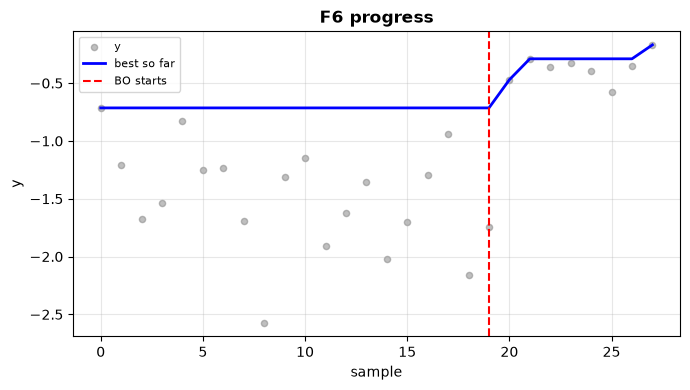

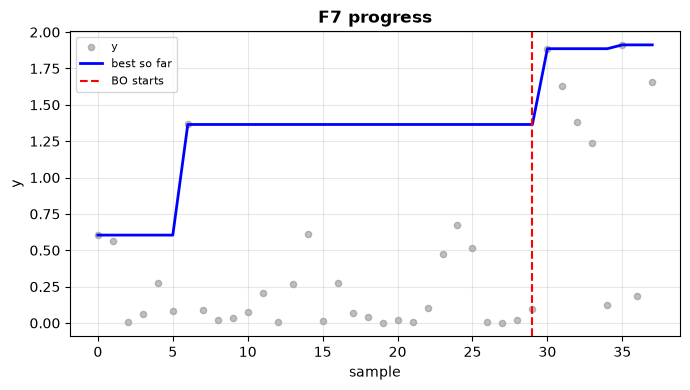

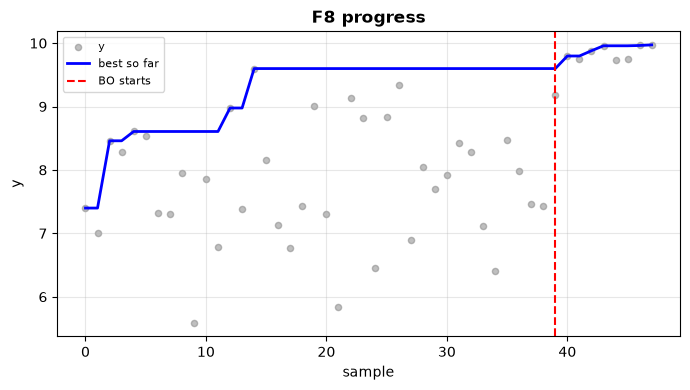

Function           Best y    At idx
F1                 0.0008        16
F2                 0.6548        17
F3                -0.0043        18
F4                -0.2646        37
F5              8662.4050        24
F6                -0.1692        27
F7                 1.9122        35
F8                 9.9720        47


In [409]:
def plot_progress(fn):
    y=all_y[fn-1].values; ni=[10,10,15,30,20,20,30,40][fn-1]
    rm=np.maximum.accumulate(y); it=np.arange(len(y))
    fig,ax=plt.subplots(figsize=(7,4))
    ax.scatter(it,y,color='grey',s=20,alpha=.5,label='y')
    ax.plot(it,rm,color='blue',lw=2,label='best so far')
    ax.axvline(ni-1,color='red',ls='--',lw=1.5,label='BO starts')
    ax.set_xlabel('sample'); ax.set_ylabel('y'); ax.set_title(f'F{fn} progress',fontweight='bold')
    ax.legend(fontsize=8); ax.grid(alpha=.3); plt.tight_layout(); plt.show()
for fn in range(1,9): plot_progress(fn)
print(f"{'Function':<10}{'Best y':>15}{'At idx':>10}")
for fn in range(1,9):
    y=all_y[fn-1].values; print(f"F{fn:<9}{y.max():>15.4f}{int(np.argmax(y)):>10}")

## Acquisition alignment across dimensions

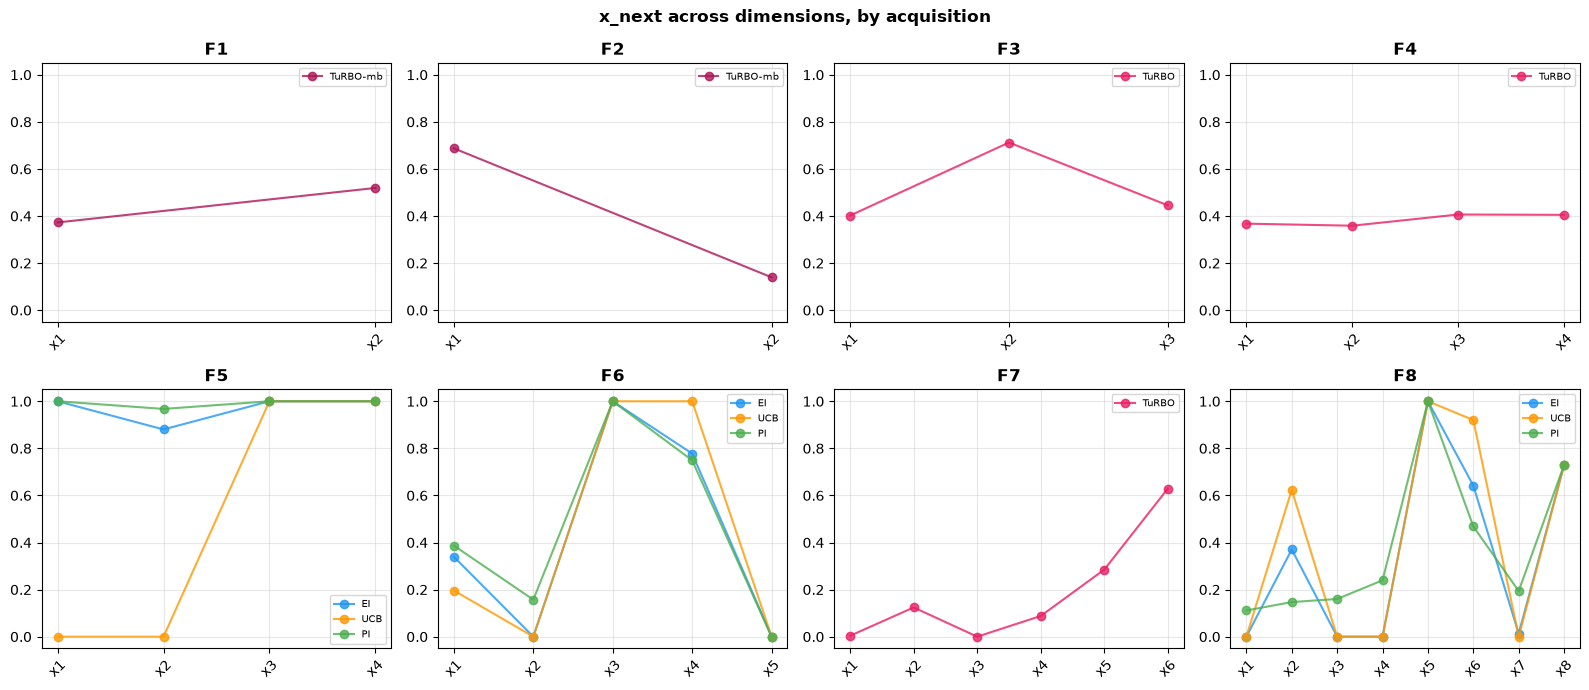

In [410]:
fig,axes=plt.subplots(2,4,figsize=(16,7)); axes=axes.ravel()
cols_all=[f'x{i}_suggested' for i in range(1,9)]
for fn in range(1,9):
    ax=axes[fn-1]; g=df_all[df_all['function']==fn]; nd=int(g['dimensions'].iloc[0])
    cs=cols_all[:nd]
    for _,r in g.iterrows():
        ax.plot(range(nd), r[cs].astype(float).values, 'o-',
                label=r['acquisition'], color=colours.get(r['acquisition'],'grey'), alpha=.8)
    ax.set_xticks(range(nd)); ax.set_xticklabels([c.replace('_suggested','') for c in cs], rotation=45)
    ax.set_ylim(-.05,1.05); ax.set_title(f'F{fn}',fontweight='bold'); ax.grid(alpha=.3); ax.legend(fontsize=7)
fig.suptitle('x_next across dimensions, by acquisition', fontweight='bold'); plt.tight_layout(); plt.show()